In [1]:
getwd()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [2]:
.libPaths()

[1] "/fast/home/y/ykazci/R/x86_64-unknown-linux-gnu-library/4.3"               
[2] "/gnu/store/5bw3l7k55lrjdcvgmb3q7c2vh7k61liy-profile/site-library"         
[3] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [3]:
here::here()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [4]:
# Retrieve the BPCells library path:

# The original BPCells guix profile contains less number of packages than the
# corresponding renv profile hydrated from the original guix profile.
# Therefore, I will use the renv library path.

bpcells_lib <- "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/renv_envs/BPCELLS/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"

In [5]:
.libPaths(new = bpcells_lib, include.site = FALSE)

In [6]:
.libPaths()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/renv_envs/BPCELLS/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"
[2] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [7]:
here::here()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [8]:
library(BPCells)

In [9]:
frags <- open_fragments_dir(here::here('bpcells_counts', "bpcell_merged_fragments_dir"))

In [10]:
frags

IterableFragments object of class "FragmentsDir"

Cells: 49470 cells with names 10X280_1:CAGATTCAGCAGCTCA, 10X365_2:ACCAATATCAATGACC ... 10X406_4:GAGAAACGTGGTGAGA
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcell_merged_fragments_dir

In [11]:
mat_lsi <- open_matrix_dir(dir = here::here('temp/mat_lsi'))

In [12]:
mat_lsi

405121 x 49470 IterableMatrix object with class MatrixDir

Row names: chr10:100006329-100006730, chr10:100009751-100010152 ... chrY:7729552-7729953
Col names: 10X280_1:CAGATTCAGCAGCTCA, 10X365_2:ACCAATATCAATGACC ... 10X406_4:GAGAAACGTGGTGAGA

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/temp/mat_lsi

In [13]:
suppressPackageStartupMessages({
  library(GenomicRanges)
  library(Biostrings)
})

In [14]:
genome_annotation_dir <- "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/renv_envs/BPCELLS/pbmc-3k/references"

In [15]:
genes <- read_gencode_transcripts(
  genome_annotation_dir, 
  release="42", 
  transcript_choice="MANE_Select",
  annotation_set = "basic", 
  features="transcript" # Make sure to set this so we don't get exons as well
)
head(genes)

chr,source,feature,start,end,score,strand,frame,gene_id,gene_type,gene_name,transcript_id,MANE_Select
<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
chr1,HAVANA,transcript,65418,71585,.,+,.,ENSG00000186092.7,protein_coding,OR4F5,ENST00000641515.2,TRUE
chr1,HAVANA,transcript,450739,451678,.,-,.,ENSG00000284733.2,protein_coding,OR4F29,ENST00000426406.4,TRUE
chr1,HAVANA,transcript,685715,686654,.,-,.,ENSG00000284662.2,protein_coding,OR4F16,ENST00000332831.5,TRUE
chr1,HAVANA,transcript,923922,944574,.,+,.,ENSG00000187634.13,protein_coding,SAMD11,ENST00000616016.5,TRUE
chr1,HAVANA,transcript,944202,959256,.,-,.,ENSG00000188976.11,protein_coding,NOC2L,ENST00000327044.7,TRUE
chr1,HAVANA,transcript,960583,965719,.,+,.,ENSG00000187961.15,protein_coding,KLHL17,ENST00000338591.8,TRUE


In [16]:
blacklist <- read_encode_blacklist(genome_annotation_dir, genome="hg38")
head(blacklist)

chr,start,end,reason
<chr>,<dbl>,<dbl>,<chr>
chr10,0,45700,Low Mappability
chr10,38481300,38596500,High Signal Region
chr10,38782600,38967900,High Signal Region
chr10,39901300,41712900,High Signal Region
chr10,41838900,42107300,High Signal Region
chr10,42279400,42322500,High Signal Region


In [17]:
chrom_sizes <- read_ucsc_chrom_sizes(genome_annotation_dir, genome="hg38")
head(chrom_sizes)

chr,start,end
<chr>,<dbl>,<int>
chr1,0,248956422
chr2,0,242193529
chr3,0,198295559
chr4,0,190214555
chr5,0,181538259
chr6,0,170805979


In [18]:
atac_qc <- qc_scATAC(frags, genes, blacklist)
head(atac_qc)

cellName,TSSEnrichment,nFrags,subNucleosomal,monoNucleosomal,multiNucleosomal,ReadsInTSS,ReadsFlankingTSS,ReadsInPromoter,ReadsInBlacklist
<chr>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
10X280_1:CAGATTCAGCAGCTCA,0,0,0,0,0,0,0,0,0
10X365_2:ACCAATATCAATGACC,0,0,0,0,0,0,0,0,0
10X365_2:ATGGTGCGTCACCTAT,0,0,0,0,0,0,0,0,0
10X280_1:ACACCTTGTCATTAGG,0,0,0,0,0,0,0,0,0
10X406_1:TATCGCGAGGCTTAAC,0,0,0,0,0,0,0,0,0
10X280_1:ACCTTGCTCCGTAAAC,0,0,0,0,0,0,0,0,0


In [19]:
atac_qc$monoNucleosomal |> table()


    0 
49470 

In [20]:
frags

IterableFragments object of class "FragmentsDir"

Cells: 49470 cells with names 10X280_1:CAGATTCAGCAGCTCA, 10X365_2:ACCAATATCAATGACC ... 10X406_4:GAGAAACGTGGTGAGA
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcell_merged_fragments_dir

In [21]:
mat_lsi <- open_matrix_dir(dir = here::here('temp/mat_lsi'))

In [22]:
mat_lsi

405121 x 49470 IterableMatrix object with class MatrixDir

Row names: chr10:100006329-100006730, chr10:100009751-100010152 ... chrY:7729552-7729953
Col names: 10X280_1:CAGATTCAGCAGCTCA, 10X365_2:ACCAATATCAATGACC ... 10X406_4:GAGAAACGTGGTGAGA

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/temp/mat_lsi

In [23]:
# check a sample of fragment files:

In [24]:
bpcells_fragments_dir <- here::here('bpcells_counts', 'bpcells_fragments')

In [25]:
list.dirs(bpcells_fragments_dir) |> head()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments"                                    
[2] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X232_1_AB_2_fragments_bpcells_dir"
[3] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X232_2_AB_2_fragments_bpcells_dir"
[4] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X232_3_AB_2_fragments_bpcells_dir"
[5] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X232_4_AB_2_fragments_bpcells_dir"
[6] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X242_1_AB_2_fragments_bpcells_dir"

In [26]:
bpcells_fragments <- list.dirs(bpcells_fragments_dir)[-1]

In [27]:
bpcells_fragments |> length()

[1] 116

In [28]:
frag_test <- open_fragments_dir(bpcells_fragments[1])

In [29]:
frag_test

IterableFragments object of class "FragmentsDir"

Cells: 711584 cells with names GCTGTTCAGGGTAATT-1, CCGTACTCACTTGCGG-1 ... AATGTCGGTTACTTTC-1
Chromosomes: 39 chromosomes with names chr1, chr10 ... KI270713.1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X232_1_AB_2_fragments_bpcells_dir

In [30]:
atac_qc_test <- qc_scATAC(frag_test, genes, blacklist)
head(atac_qc_test)

cellName,TSSEnrichment,nFrags,subNucleosomal,monoNucleosomal,multiNucleosomal,ReadsInTSS,ReadsFlankingTSS,ReadsInPromoter,ReadsInBlacklist
<chr>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
GCTGTTCAGGGTAATT-1,52.553827,32234,16836,10329,5069,5016,189,22002,523
CCGTACTCACTTGCGG-1,26.085113,96109,44462,32096,19551,7996,607,41552,894
TGGCGCATCCTCATTA-1,34.792614,57727,29018,17461,11248,6501,370,31385,661
AAGATAGTCACAACAC-1,25.472151,82345,41412,24743,16190,8760,681,44821,1014
ATCCCTGTCTCGTAGA-1,0.990099,2039,992,902,145,10,8,87,20
CTCAGAAGTACCAAGG-1,21.561911,140000,62941,47666,29393,9789,899,53548,1315


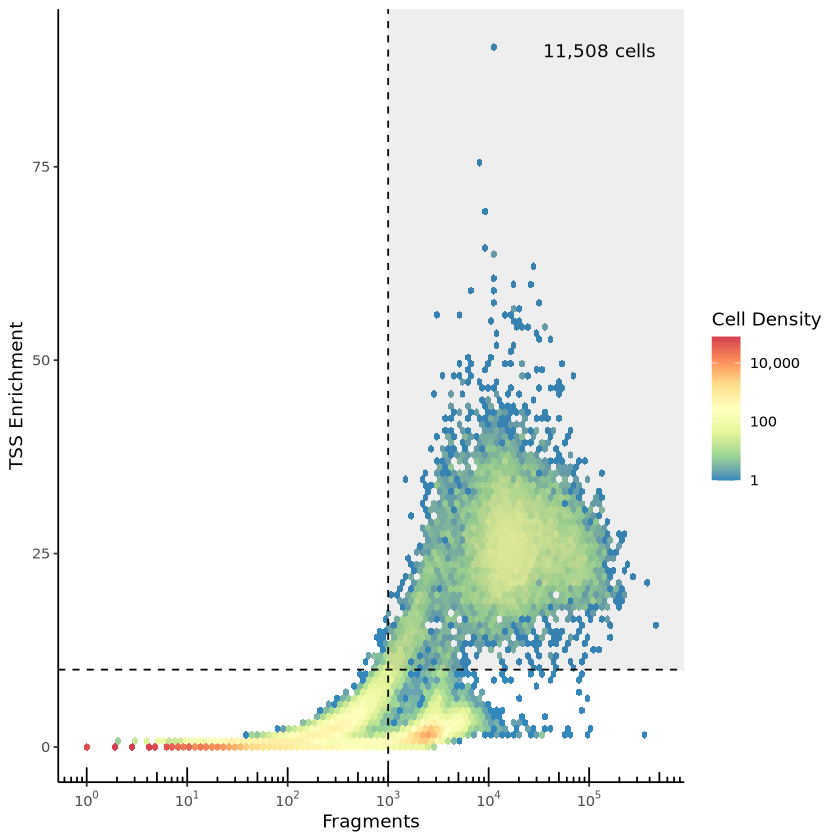

In [31]:
plot_tss_scatter(atac_qc_test, min_frags=1000, min_tss=10)

In [32]:
# it is working. Then, the problem is in my merged fragment object from selected cells.

In [33]:
# I will try to form it again:

In [34]:
fragment_paths <- c(
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X280_1_ABCD_1_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X280_2_ABCD_1_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X280_3_ABCD_1_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X290_1_ABCD_1_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X290_2_ABCD_1_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X346_1_ABCD_1_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X346_2_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X346_3_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X346_4_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X365_2_ABCDE_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X365_4_ABCDE_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X370_1_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X370_2_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X370_3_ABCDE_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X370_4_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X402_1_ABCD_1_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X406_1_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X406_2_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X406_3_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X406_4_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X406_5_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X406_6_ABCD_2_atac_fragments_bpcells_dir",
  "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X406_7_ABCD_2_atac_fragments_bpcells_dir"
)


In [35]:
fragment_objects <- lapply(fragment_paths, open_fragments_dir)

In [36]:
prefixes <- fragment_paths |> basename() |> stringr::str_split_i(pattern = "_A", i = 1)

In [37]:
# Function to apply prefix to cell barcodes
add_prefix_to_cells <- function(fragment_obj, prefix) {
  prefix_cell_names(fragment_obj, paste0(prefix, ":"))
}

In [38]:
# Apply the prefix to each fragment object:

prefixed_fragments <- Map(add_prefix_to_cells, fragment_objects, prefixes)

In [39]:
prefixed_fragments

[[1]]
IterableFragments object of class "CellPrefix"

Cells: 716572 cells with names 10X280_1:CTTTGGTGTCGTAAAT-1, 10X280_1:GTGTGTTAGTTAGGCT-1 ... 10X280_1:AGTCAAGAGTCGCAAT-1
Chromosomes: 40 chromosomes with names chr10, chr11 ... chr22_KI270733v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X280_1_ABCD_1_atac_fragments_bpcells_dir
2. Prefix cells names with: 10X280_1:

[[2]]
IterableFragments object of class "CellPrefix"

Cells: 716189 cells with names 10X280_2:TTTGGCTGTTGAGGTC-1, 10X280_2:GCCCGTTGTGAATCGC-1 ... 10X280_2:TCTTCAAGTAGTCAAT-1
Chromosomes: 39 chromosomes with names chr10, chr11 ... chr22_KI270734v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fr

In [40]:
# Merge all fragment objects

merged_fragments <- do.call(c, prefixed_fragments)

In [41]:
merged_fragments

IterableFragments object of class "MergeFragments"

Cells: 15370189 cells with names 10X280_1:CTTTGGTGTCGTAAAT-1, 10X280_1:GTGTGTTAGTTAGGCT-1 ... 10X406_7:AGTAACGAGGTTAGCT-1
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Merge 23 fragments objects of classes: CellPrefix, CellPrefix ... CellPrefix

In [42]:
# retrieve cell ids to subset:

metadata <- readRDS(file = here::here('r_objects', 'metadata.RDS'))

In [43]:
cell_ids <- metadata$CellID

In [44]:
prefixed_fragments[[1]]

IterableFragments object of class "CellPrefix"

Cells: 716572 cells with names 10X280_1:CTTTGGTGTCGTAAAT-1, 10X280_1:GTGTGTTAGTTAGGCT-1 ... 10X280_1:AGTCAAGAGTCGCAAT-1
Chromosomes: 40 chromosomes with names chr10, chr11 ... chr22_KI270733v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X280_1_ABCD_1_atac_fragments_bpcells_dir
2. Prefix cells names with: 10X280_1:

In [45]:
prefixed_fragments[[1]] |> slotNames()

[1] "fragments" "prefix"

In [46]:
prefixed_fragments[[1]]@fragments

IterableFragments object of class "FragmentsDir"

Cells: 716572 cells with names CTTTGGTGTCGTAAAT-1, GTGTGTTAGTTAGGCT-1 ... AGTCAAGAGTCGCAAT-1
Chromosomes: 40 chromosomes with names chr10, chr11 ... chr22_KI270733v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X280_1_ABCD_1_atac_fragments_bpcells_dir

In [47]:
merged_fragments |> slotNames()

[1] "fragments_list"

In [48]:
merged_fragments@fragments_list

[[1]]
IterableFragments object of class "CellPrefix"

Cells: 716572 cells with names 10X280_1:CTTTGGTGTCGTAAAT-1, 10X280_1:GTGTGTTAGTTAGGCT-1 ... 10X280_1:AGTCAAGAGTCGCAAT-1
Chromosomes: 40 chromosomes with names chr10, chr11 ... chr22_KI270733v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fragments/10X280_1_ABCD_1_atac_fragments_bpcells_dir
2. Prefix cells names with: 10X280_1:

[[2]]
IterableFragments object of class "CellPrefix"

Cells: 716189 cells with names 10X280_2:TTTGGCTGTTGAGGTC-1, 10X280_2:GCCCGTTGTGAATCGC-1 ... 10X280_2:TCTTCAAGTAGTCAAT-1
Chromosomes: 39 chromosomes with names chr10, chr11 ... chr22_KI270734v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/bpcells_fr

In [49]:
merged_fragments |> write_fragments_dir(dir = here::here('bpcells_counts', 'combined_fragments'))

IterableFragments object of class "FragmentsDir"

Cells: 15370189 cells with names 10X280_1:CTTTGGTGTCGTAAAT-1, 10X280_1:GTGTGTTAGTTAGGCT-1 ... 10X406_7:AGTAACGAGGTTAGCT-1
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/combined_fragments

In [50]:
merged_fragments <- open_fragments_dir(dir = here::here('bpcells_counts', 'combined_fragments'))

In [51]:
merged_fragments

IterableFragments object of class "FragmentsDir"

Cells: 15370189 cells with names 10X280_1:CTTTGGTGTCGTAAAT-1, 10X280_1:GTGTGTTAGTTAGGCT-1 ... 10X406_7:AGTAACGAGGTTAGCT-1
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/combined_fragments

In [52]:
subsetted_cells <- select_cells(fragments = merged_fragments, cell_selection = cell_ids)

In [53]:
subsetted_cells

IterableFragments object of class "CellSelectName"

Cells: 49470 cells with names 10X280_1:CAGATTCAGCAGCTCA, 10X365_2:ACCAATATCAATGACC ... 10X406_4:GAGAAACGTGGTGAGA
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/combined_fragments
2. Select 49470 cells by name: 10X280_1:CAGATTCAGCAGCTCA, 10X365_2:ACCAATATCAATGACC ... 10X406_4:GAGAAACGTGGTGAGA

In [54]:
subsetted_cells |> slotNames()

[1] "fragments"  "cell_names"

In [55]:
subsetted_cells <- subsetted_cells |> write_fragments_dir(dir = here::here('bpcells_counts', 'subsetted_fragments'))

In [56]:
subsetted_cells

IterableFragments object of class "FragmentsDir"

Cells: 49470 cells with names 10X280_1:CAGATTCAGCAGCTCA, 10X365_2:ACCAATATCAATGACC ... 10X406_4:GAGAAACGTGGTGAGA
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/subsetted_fragments

In [57]:
atac_qc_test <- qc_scATAC(subsetted_cells, genes, blacklist)
head(atac_qc_test)

cellName,TSSEnrichment,nFrags,subNucleosomal,monoNucleosomal,multiNucleosomal,ReadsInTSS,ReadsFlankingTSS,ReadsInPromoter,ReadsInBlacklist
<chr>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
10X280_1:CAGATTCAGCAGCTCA,0,0,0,0,0,0,0,0,0
10X365_2:ACCAATATCAATGACC,0,0,0,0,0,0,0,0,0
10X365_2:ATGGTGCGTCACCTAT,0,0,0,0,0,0,0,0,0
10X280_1:ACACCTTGTCATTAGG,0,0,0,0,0,0,0,0,0
10X406_1:TATCGCGAGGCTTAAC,0,0,0,0,0,0,0,0,0
10X280_1:ACCTTGCTCCGTAAAC,0,0,0,0,0,0,0,0,0


In [58]:
atac_qc_test <- qc_scATAC(merged_fragments, genes, blacklist)
head(atac_qc_test)

cellName,TSSEnrichment,nFrags,subNucleosomal,monoNucleosomal,multiNucleosomal,ReadsInTSS,ReadsFlankingTSS,ReadsInPromoter,ReadsInBlacklist
<chr>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
10X280_1:CTTTGGTGTCGTAAAT-1,1.596160,607041,378522,171024,57495,1330,1650,20533,10946
10X280_1:GTGTGTTAGTTAGGCT-1,24.386763,32250,13676,12250,6324,2734,222,13489,277
10X280_1:GTAAGCTTCTTGCAGG-1,2.376238,3314,2057,923,334,24,13,174,46
10X280_1:CGTAATGGTACCAGGT-1,35.467035,43550,19995,15128,8427,4621,258,22729,381
10X280_1:ACATAGCTCTCCTCAA-1,28.440009,19494,8364,7286,3844,1824,127,9041,188
10X280_1:TTCAACCGTGCACGCA-1,35.345962,30328,14046,10611,5671,3088,173,14606,278


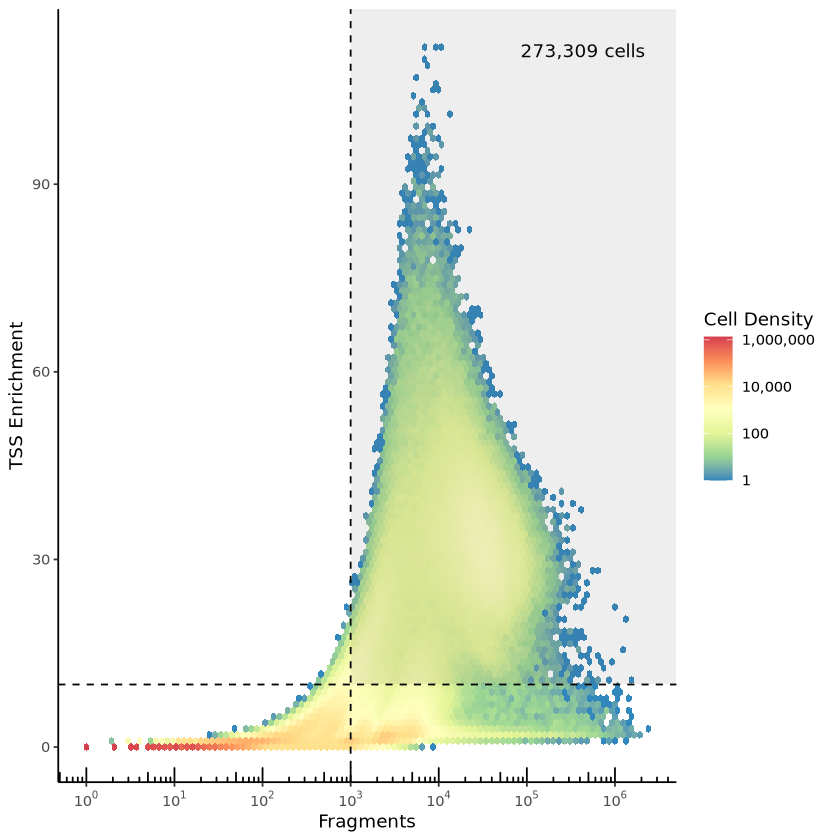

In [60]:
plot_tss_scatter(atac_qc_test, min_frags=1000, min_tss=10)

In [63]:
cellNames(merged_fragments) |> length()

[1] 15370189

In [64]:
cellNames(merged_fragments)  |> head()

[1] "10X280_1:CTTTGGTGTCGTAAAT-1" "10X280_1:GTGTGTTAGTTAGGCT-1"
[3] "10X280_1:GTAAGCTTCTTGCAGG-1" "10X280_1:CGTAATGGTACCAGGT-1"
[5] "10X280_1:ACATAGCTCTCCTCAA-1" "10X280_1:TTCAACCGTGCACGCA-1"

In [65]:
cell_ids |> class()

[1] "character"

In [66]:
table(cellNames(merged_fragments) %in% cell_ids)


   FALSE 
15370189 

In [67]:
cell_ids |> head()

[1] "10X280_1:CAGATTCAGCAGCTCA" "10X365_2:ACCAATATCAATGACC"
[3] "10X365_2:ATGGTGCGTCACCTAT" "10X280_1:ACACCTTGTCATTAGG"
[5] "10X406_1:TATCGCGAGGCTTAAC" "10X280_1:ACCTTGCTCCGTAAAC"

In [68]:
metadata$`_index` |> head()

[1] "10X280_1:CAGATTCAGCAGCTCA" "10X365_2:ACCAATATCAATGACC"
[3] "10X365_2:ATGGTGCGTCACCTAT" "10X280_1:ACACCTTGTCATTAGG"
[5] "10X406_1:TATCGCGAGGCTTAAC" "10X280_1:ACCTTGCTCCGTAAAC"

In [69]:
metadata$CellID |> head()

[1] "10X280_1:CAGATTCAGCAGCTCA" "10X365_2:ACCAATATCAATGACC"
[3] "10X365_2:ATGGTGCGTCACCTAT" "10X280_1:ACACCTTGTCATTAGG"
[5] "10X406_1:TATCGCGAGGCTTAAC" "10X280_1:ACCTTGCTCCGTAAAC"

In [70]:
metadata |> head() |> print()

                          orig.ident nCount_RNA nFeature_RNA
10X280_1:CAGATTCAGCAGCTCA     10X280       4735         2198
10X365_2:ACCAATATCAATGACC     10X365       4031         1628
10X365_2:ATGGTGCGTCACCTAT     10X365       4454         1277
10X280_1:ACACCTTGTCATTAGG     10X280       3976         1850
10X406_1:TATCGCGAGGCTTAAC     10X406       3896         1631
10X280_1:ACCTTGCTCCGTAAAC     10X280       3794         1556
                          before_filtering_orig.ident
10X280_1:CAGATTCAGCAGCTCA                      10X280
10X365_2:ACCAATATCAATGACC                      10X365
10X365_2:ATGGTGCGTCACCTAT                      10X365
10X280_1:ACACCTTGTCATTAGG                      10X280
10X406_1:TATCGCGAGGCTTAAC                      10X406
10X280_1:ACCTTGCTCCGTAAAC                      10X280
                          before_filtering_nCount_RNA
10X280_1:CAGATTCAGCAGCTCA                        4936
10X365_2:ACCAATATCAATGACC                        4243
10X365_2:ATGGTGCGTCACCTAT        

In [72]:
metadata |> dplyr::select(barcode, CellID, `_index`) |> head()

,barcode,CellID,_index
,<chr>,<chr>,<chr>
10X280_1:CAGATTCAGCAGCTCA,CAGATTCAGCAGCTCA-1,10X280_1:CAGATTCAGCAGCTCA,10X280_1:CAGATTCAGCAGCTCA
10X365_2:ACCAATATCAATGACC,ACCAATATCAATGACC-1,10X365_2:ACCAATATCAATGACC,10X365_2:ACCAATATCAATGACC
10X365_2:ATGGTGCGTCACCTAT,ATGGTGCGTCACCTAT-1,10X365_2:ATGGTGCGTCACCTAT,10X365_2:ATGGTGCGTCACCTAT
10X280_1:ACACCTTGTCATTAGG,ACACCTTGTCATTAGG-1,10X280_1:ACACCTTGTCATTAGG,10X280_1:ACACCTTGTCATTAGG
10X406_1:TATCGCGAGGCTTAAC,TATCGCGAGGCTTAAC-1,10X406_1:TATCGCGAGGCTTAAC,10X406_1:TATCGCGAGGCTTAAC
10X280_1:ACCTTGCTCCGTAAAC,ACCTTGCTCCGTAAAC-1,10X280_1:ACCTTGCTCCGTAAAC,10X280_1:ACCTTGCTCCGTAAAC


In [76]:
# there is a mismatch between cell id format in fragments file and metadata version.
# I will form a correct format:

cell_ids_correct <- metadata$CellID |> stringr::str_split_i(pattern = ':', i = 1) |> paste0(':', metadata$barcode)

In [77]:
cell_ids_correct |> head()

[1] "10X280_1:CAGATTCAGCAGCTCA-1" "10X365_2:ACCAATATCAATGACC-1"
[3] "10X365_2:ATGGTGCGTCACCTAT-1" "10X280_1:ACACCTTGTCATTAGG-1"
[5] "10X406_1:TATCGCGAGGCTTAAC-1" "10X280_1:ACCTTGCTCCGTAAAC-1"

In [78]:
# check if names overlap:

table(cellNames(merged_fragments) %in% cell_ids_correct)


   FALSE     TRUE 
15320719    49470 

In [79]:
subsetted_cells <- select_cells(fragments = merged_fragments, cell_selection = cell_ids_correct)

In [80]:
subsetted_cells

IterableFragments object of class "CellSelectName"

Cells: 49470 cells with names 10X280_1:CAGATTCAGCAGCTCA-1, 10X365_2:ACCAATATCAATGACC-1 ... 10X406_4:GAGAAACGTGGTGAGA-1
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/combined_fragments
2. Select 49470 cells by name: 10X280_1:CAGATTCAGCAGCTCA-1, 10X365_2:ACCAATATCAATGACC-1 ... 10X406_4:GAGAAACGTGGTGAGA-1

In [81]:
subsetted_cells <- subsetted_cells |> write_fragments_dir(dir = here::here('bpcells_counts', 'subsetted_fragments'))

In [82]:
subsetted_cells

IterableFragments object of class "FragmentsDir"

Cells: 49470 cells with names 10X280_1:CAGATTCAGCAGCTCA-1, 10X365_2:ACCAATATCAATGACC-1 ... 10X406_4:GAGAAACGTGGTGAGA-1
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/subsetted_fragments

In [83]:
atac_qc <- qc_scATAC(subsetted_cells, genes, blacklist)
head(atac_qc)

cellName,TSSEnrichment,nFrags,subNucleosomal,monoNucleosomal,multiNucleosomal,ReadsInTSS,ReadsFlankingTSS,ReadsInPromoter,ReadsInBlacklist
<chr>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
10X280_1:CAGATTCAGCAGCTCA-1,30.45792,24171,12179,8185,3807,2461,160,11967,243
10X365_2:ACCAATATCAATGACC-1,45.89400,15654,8498,5062,2094,1970,85,9232,152
10X365_2:ATGGTGCGTCACCTAT-1,39.60396,12236,6178,4184,1874,1560,78,7325,90
10X280_1:ACACCTTGTCATTAGG-1,38.66027,22027,10117,7979,3931,2499,128,11388,188
10X406_1:TATCGCGAGGCTTAAC-1,16.42744,29874,8226,16030,5618,1402,169,7435,147
10X280_1:ACCTTGCTCCGTAAAC-1,27.27443,20119,9121,6974,4024,2190,159,10674,182


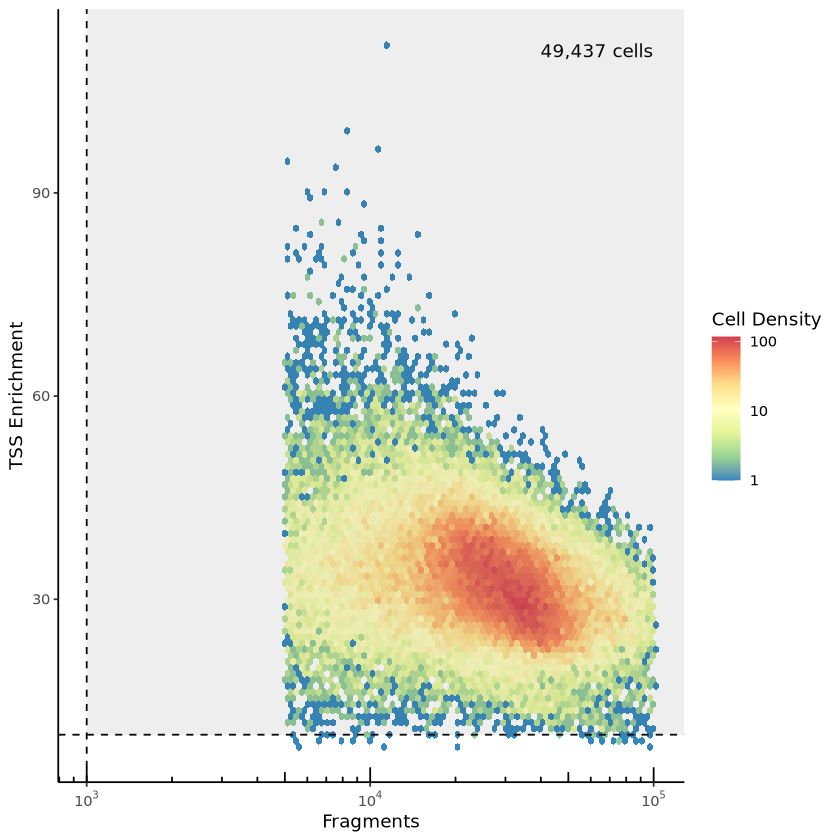

In [84]:
plot_tss_scatter(atac_qc, min_frags=1000, min_tss=10)

In [85]:
# as expected, because our data is qc filtered before.

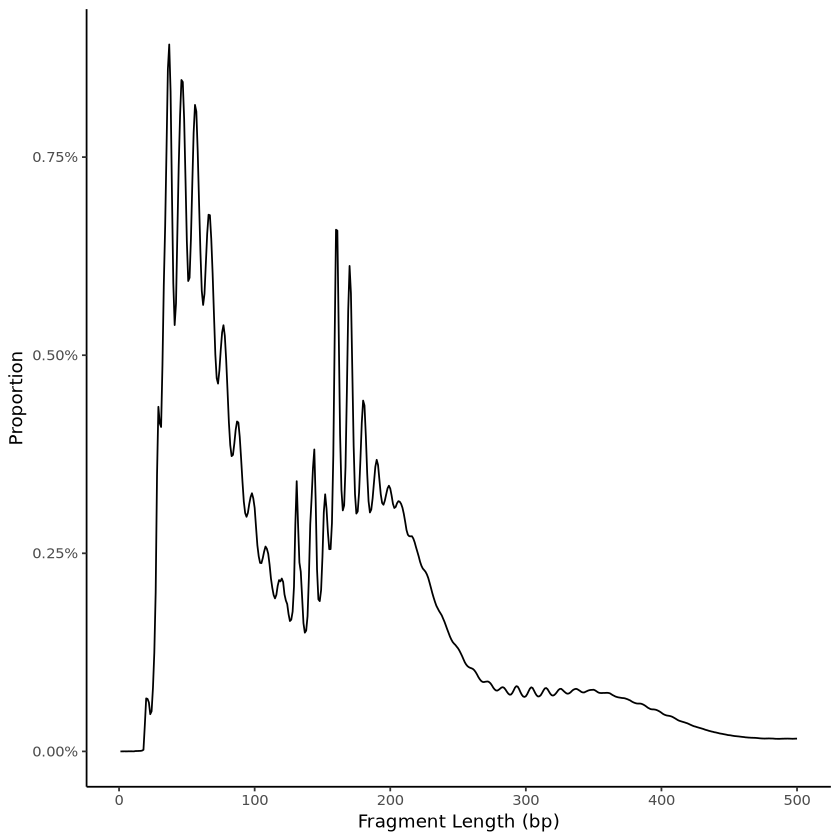

In [86]:
plot_fragment_length(fragments = subsetted_cells)

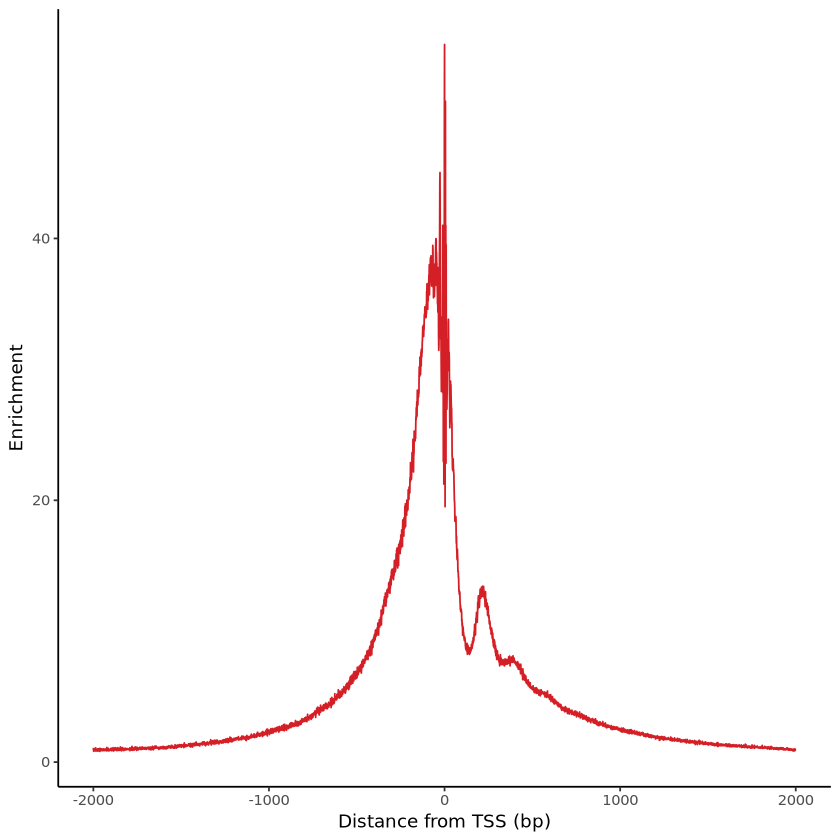

In [87]:
plot_tss_profile(fragments = subsetted_cells, genes)

In [88]:
mat_lsi

405121 x 49470 IterableMatrix object with class MatrixDir

Row names: chr10:100006329-100006730, chr10:100009751-100010152 ... chrY:7729552-7729953
Col names: 10X280_1:CAGATTCAGCAGCTCA, 10X365_2:ACCAATATCAATGACC ... 10X406_4:GAGAAACGTGGTGAGA

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/temp/mat_lsi

In [89]:
mat_lsi |> rownames() |> head()

[1] "chr10:100006329-100006730" "chr10:100009751-100010152"
[3] "chr10:100016741-100017142" "chr10:100019766-100020167"
[5] "chr10:100020276-100020677" "chr10:100020877-100021278"

In [90]:
temp_DF <- data.frame(chr = rownames(mat_lsi) |> stringr::str_split_i(pattern = ':', i = 1) ,
                      start = rownames(mat_lsi) |> stringr::str_split_i(pattern = ':', i = 2) |> stringr::str_split_i(pattern = '-', i = 1) |> as.numeric(),
                      end = rownames(mat_lsi) |> stringr::str_split_i(pattern = ':', i = 2) |> stringr::str_split_i(pattern = '-', i = 2) |> as.numeric())

In [91]:
temp_DF |> head()

,chr,start,end
,<chr>,<dbl>,<dbl>
1,chr10,100006329,100006730
2,chr10,100009751,100010152
3,chr10,100016741,100017142
4,chr10,100019766,100020167
5,chr10,100020276,100020677
6,chr10,100020877,100021278


In [92]:
temp_DF |> dim()

[1] 405121      3

In [93]:
suppressPackageStartupMessages({
  library(GenomicRanges)
  library(Biostrings)
})

In [94]:
peaks_sorted <- dplyr::arrange(temp_DF, chr, start)

In [95]:
peaks_sorted |> head()

,chr,start,end
,<chr>,<dbl>,<dbl>
1,chr1,9978,10379
2,chr1,180693,181094
3,chr1,181291,181692
4,chr1,184271,184672
5,chr1,190642,191043
6,chr1,191278,191679


In [97]:
# my peaks were calles using MACS2 by the authors. Therefore, most likely, they are zero-based.

# convert to 1-based version  follwing the BPCells tutorial:

peaks_gr <- dplyr::mutate(peaks_sorted, start = start + 1)  |> as("GenomicRanges")

In [98]:
peaks_gr

GRanges object with 405121 ranges and 0 metadata columns:
           seqnames            ranges strand
              <Rle>         <IRanges>  <Rle>
       [1]     chr1        9979-10379      *
       [2]     chr1     180694-181094      *
       [3]     chr1     181292-181692      *
       [4]     chr1     184272-184672      *
       [5]     chr1     190643-191043      *
       ...      ...               ...    ...
  [405117]     chrY 20575482-20575882      *
  [405118]     chrY 26670710-26671110      *
  [405119]     chrY 56832451-56832851      *
  [405120]     chrY 56834078-56834478      *
  [405121]     chrY 56836704-56837104      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [100]:
selected_motifs <- c(
  "CEBPA" = "ENSG00000245848_LINE568_CEBPA_D_N4",
  "EOMES" = "ENSG00000163508_LINE3544_EOMES_D_N1", 
  "SPI1" = "ENSG00000066336_LINE1813_SPI1_D_N5",
  "CTCF" = "ENSG00000102974_LINE747_CTCF_D_N67"
)

In [101]:
suppressWarnings({
  motif_positions <- motifmatchr::matchMotifs(
      chromVARmotifs::human_pwms_v2[selected_motifs], 
      peaks_gr, genome="hg38", out="positions")
})




Attaching package: 'rtracklayer'


The following object is masked from 'package:BiocIO':

    FileForFormat




In [102]:
names(motif_positions) <- names(selected_motifs)
motif_positions

GRangesList object of length 4:
$CEBPA
GRanges object with 20616 ranges and 1 metadata column:
          seqnames              ranges strand |     score
             <Rle>           <IRanges>  <Rle> | <numeric>
      [1]     chr1       916817-916826      - |   8.12722
      [2]     chr1     1071327-1071336      + |   7.90994
      [3]     chr1     2100237-2100246      - |   8.07170
      [4]     chr1     2234443-2234452      + |   8.12722
      [5]     chr1     2903832-2903841      - |   8.83400
      ...      ...                 ...    ... .       ...
  [20612]     chrX 152197828-152197837      - |   8.06273
  [20613]     chrX 153628256-153628265      + |   7.86407
  [20614]     chrX 154715294-154715303      + |   7.96416
  [20615]     chrX 154793484-154793493      + |   8.07170
  [20616]     chrX 155094577-155094586      + |   7.86407
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

...
<3 more elements>

In [103]:
subsetted_cells

IterableFragments object of class "FragmentsDir"

Cells: 49470 cells with names 10X280_1:CAGATTCAGCAGCTCA-1, 10X365_2:ACCAATATCAATGACC-1 ... 10X406_4:GAGAAACGTGGTGAGA-1
Chromosomes: 45 chromosomes with names chr10, chr11 ... chr1_KI270711v1

Queued Operations:
1. Read compressed fragments from directory /fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/bpcells_counts/subsetted_fragments

In [104]:
table(cellNames(subsetted_cells) == cell_ids_correct)


 TRUE 
49470 

In [106]:
options(repr.plot.width = 15, repr.plot.height = 7)

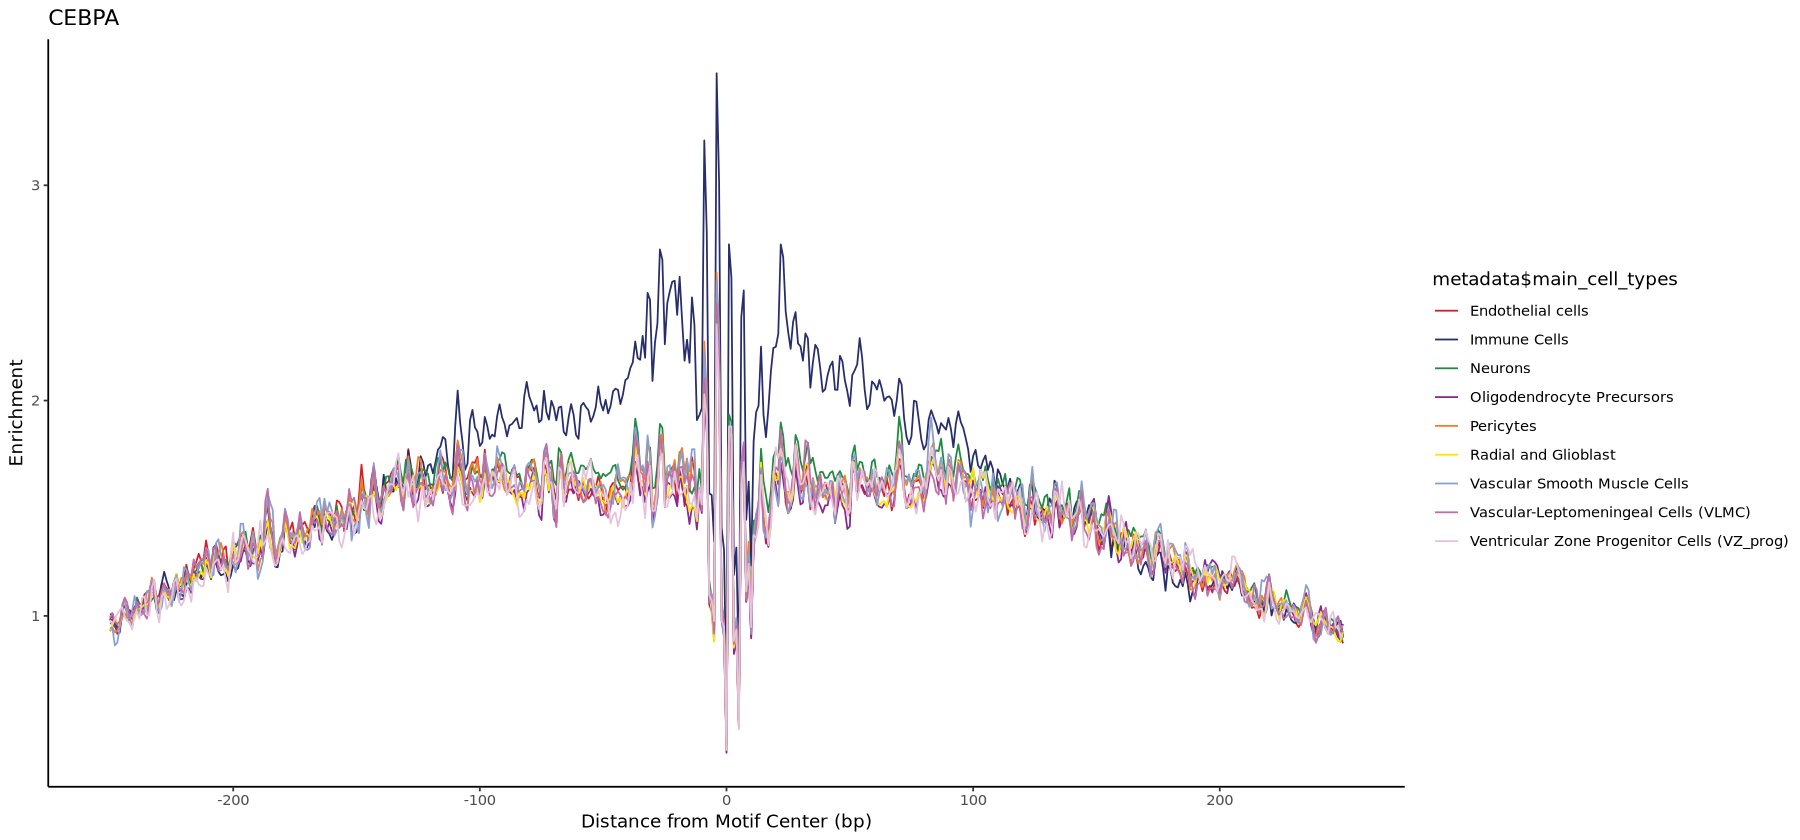

In [107]:
plot_tf_footprint(
  subsetted_cells,
  motif_positions$CEBPA,
  cell_groups = metadata$main_cell_types,
  flank = 250,
  smooth = 2
) +
  ggplot2::labs(title="CEBPA")

In [108]:
options(repr.plot.width = 30, repr.plot.height = 24)

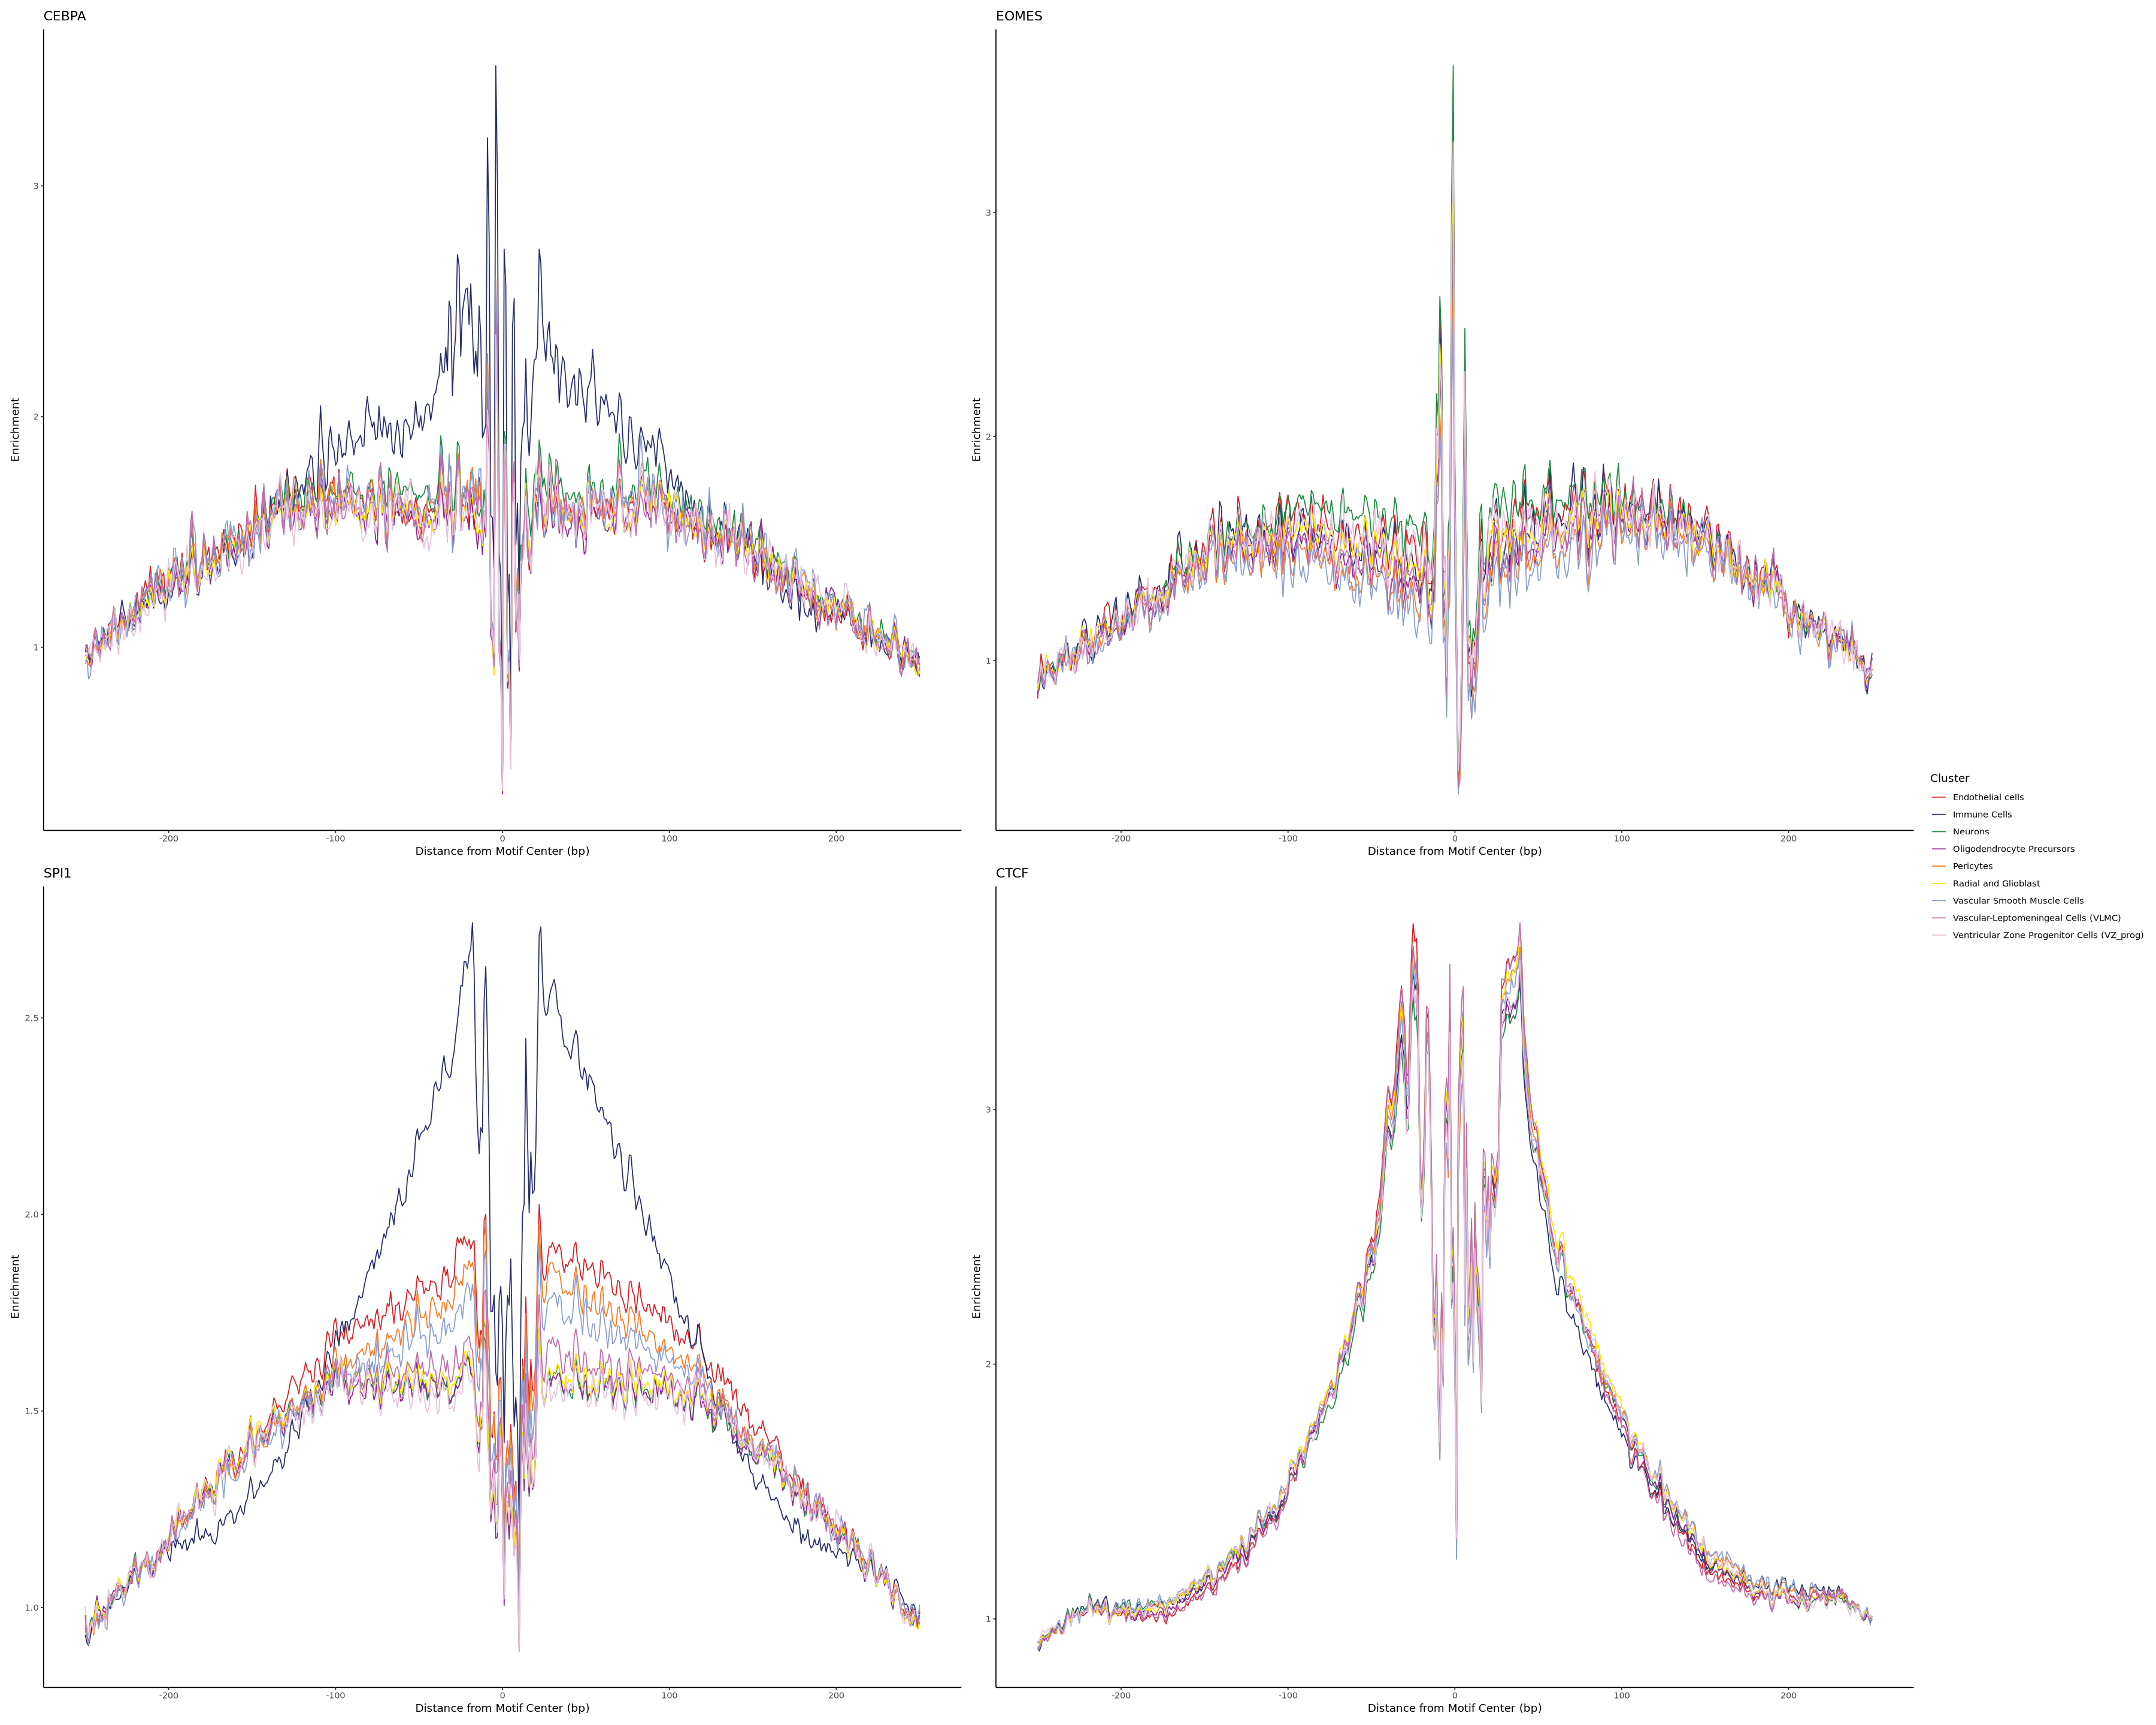

In [109]:
footprinting_plots <- list()
for (motif in names(selected_motifs)) {
  footprinting_plots[[motif]] <- plot_tf_footprint(
    subsetted_cells, 
    motif_positions[[motif]], 
    cell_groups = metadata$main_cell_types, 
    flank=250,
    smooth=2) +
    ggplot2::labs(title=motif, color="Cluster")
}
patchwork::wrap_plots(footprinting_plots, guides="collect")

In [110]:
chromVARmotifs::human_pwms_v2 |> head()

PWMatrixList of length 6
names(6): ENSG00000008196_LINE2_TFAP2B_D_N1 ...

In [112]:
chromVARmotifs::human_pwms_v2 |> length()

[1] 870

In [114]:
my_human_pwms_v2 <- chromVARmotifs::human_pwms_v2

In [115]:
my_human_pwms_v2

PWMatrixList of length 870
names(870): ENSG00000008196_LINE2_TFAP2B_D_N1 ...

In [116]:
my_human_pwms_v2 |> names() |> head()

[1] "ENSG00000008196_LINE2_TFAP2B_D_N1"  "ENSG00000008197_LINE6_TFAP2D_D"    
[3] "ENSG00000087510_LINE7_TFAP2C_D_N3"  "ENSG00000116819_LINE19_TFAP2E_I"   
[5] "ENSG00000137203_LINE29_TFAP2A_D_N3" "ENSG00000116017_LINE44_ARID3A_D_N1"

In [118]:
names(my_human_pwms_v2) |> stringr::str_detect(pattern = 'SOX17') |> table()


FALSE  TRUE 
  869     1 

In [119]:
names(my_human_pwms_v2) |> stringr::str_subset(pattern = 'SOX17')

[1] "ENSG00000164736_LINE3425_SOX17_D"

In [125]:
motif_selected <- c("SOX17" = "ENSG00000164736_LINE3425_SOX17_D")

In [126]:
motif_selected

SOX17 
"ENSG00000164736_LINE3425_SOX17_D"

In [127]:
suppressWarnings({
  motif_positions <- motifmatchr::matchMotifs(
      chromVARmotifs::human_pwms_v2[motif_selected], 
      peaks_gr, genome="hg38", out="positions")
})

In [130]:
names(motif_positions) <- names(motif_selected)
motif_positions

GRangesList object of length 1:
$SOX17
GRanges object with 24239 ranges and 1 metadata column:
          seqnames              ranges strand |     score
             <Rle>           <IRanges>  <Rle> | <numeric>
      [1]     chr1     1158300-1158317      + |   8.07209
      [2]     chr1     1238285-1238302      + |   7.65164
      [3]     chr1     1381570-1381587      - |   8.40258
      [4]     chr1     1842960-1842977      - |  11.35587
      [5]     chr1     1845765-1845782      - |   7.99474
      ...      ...                 ...    ... .       ...
  [24235]     chrX 155641643-155641660      - |   7.67399
  [24236]     chrY     2841564-2841581      - |   7.70426
  [24237]     chrY     2957757-2957774      + |  11.08265
  [24238]     chrY     2957855-2957872      + |   7.74599
  [24239]     chrY   14393426-14393443      + |   9.15476
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


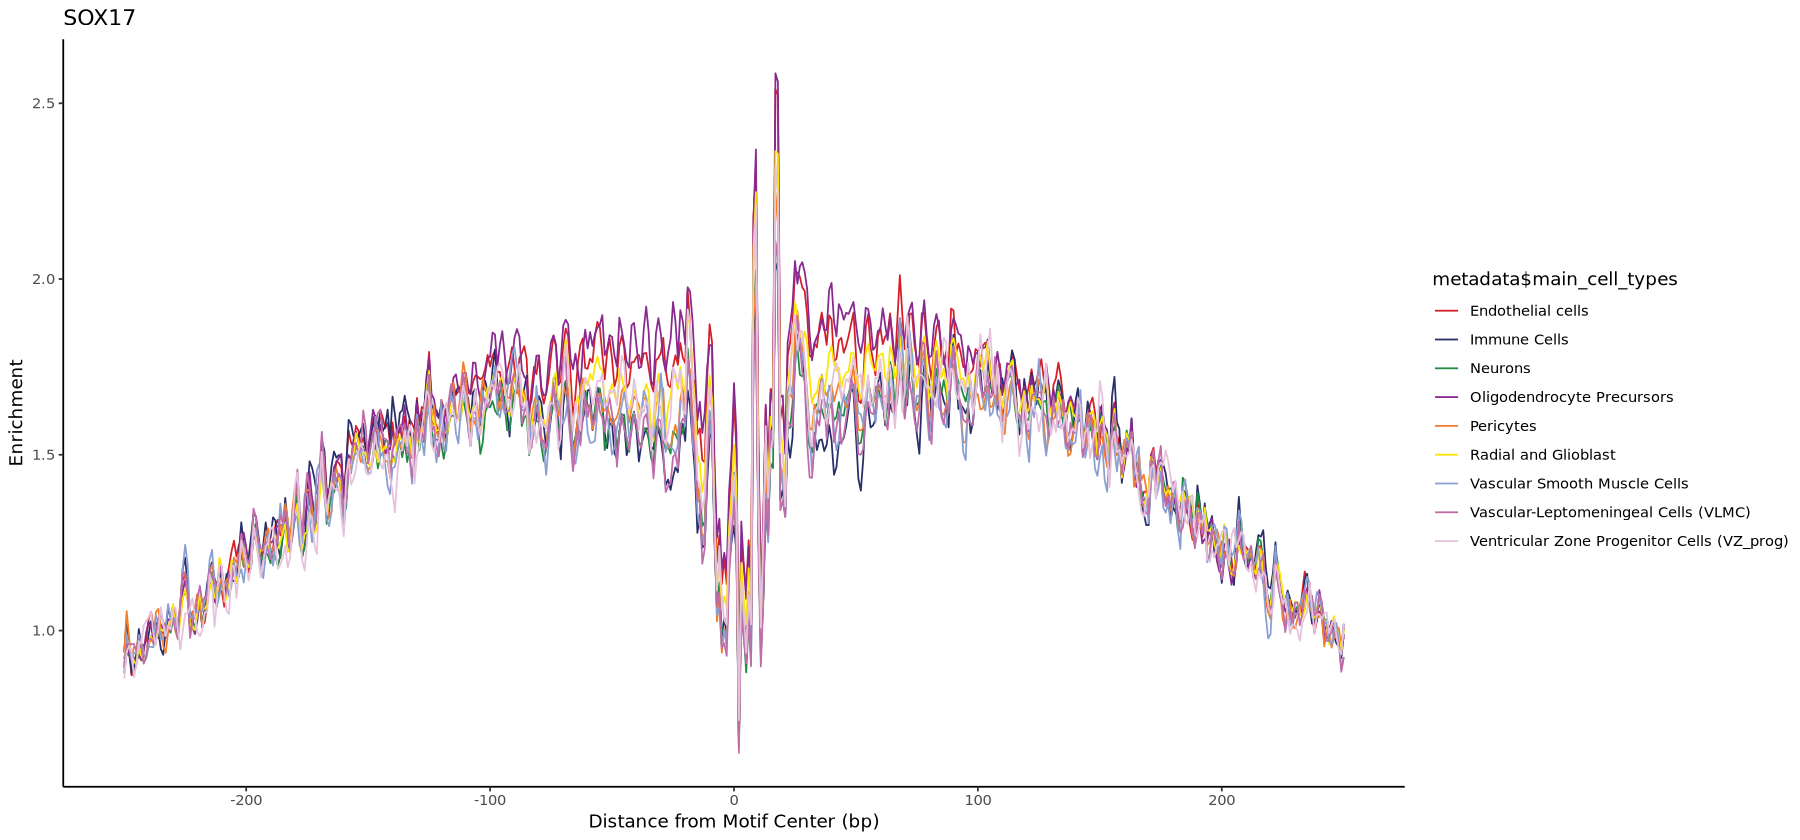

In [131]:
options(repr.plot.width = 15, repr.plot.height = 7)

plot_tf_footprint(
  subsetted_cells,
  motif_positions$SOX17,
  cell_groups = metadata$main_cell_types,
  flank = 250,
  smooth = 2
) +
  ggplot2::labs(title="SOX17")

In [132]:
names(my_human_pwms_v2) |> stringr::str_subset(pattern = 'LEF1')

[1] "ENSG00000138795_LINE3404_LEF1_D_N1"

In [146]:
analyze_single_tf_footprint <- function(tf_name, peaks_gr, subsetted_cells, metadata) {
  suppressPackageStartupMessages({
    library(stringr)
    library(motifmatchr)
    library(chromVARmotifs)
    library(ggplot2)
    library(patchwork)
  })
  
  # Find motif name for the given TF
  motif_match <- names(my_human_pwms_v2) |> str_subset(pattern = tf_name)
  
  if (length(motif_match) == 0) {
    stop("No motif found for the given TF. Check the input name.")
  }
  
  # Create named vector for selected motif(s)
  selected_motifs <- setNames(motif_match, tf_name)
  
  message("Motifs selected: ", paste(names(selected_motifs), collapse=", "))
  
  # Run motif matching
  suppressWarnings({
    motif_positions <- motifmatchr::matchMotifs(
      chromVARmotifs::human_pwms_v2[selected_motifs], 
      peaks_gr, genome="hg38", out="positions")
  })
  
  names(motif_positions) <- names(selected_motifs)
  
  # Generate footprinting plots

    plot_tf_footprint(
      subsetted_cells,
      motif_positions[[1]],
      cell_groups = metadata$main_cell_types,
      flank = 250,
      smooth = 2
    ) +
      ggplot2::labs(title=names(selected_motifs))
  
}


Motifs selected: LEF1



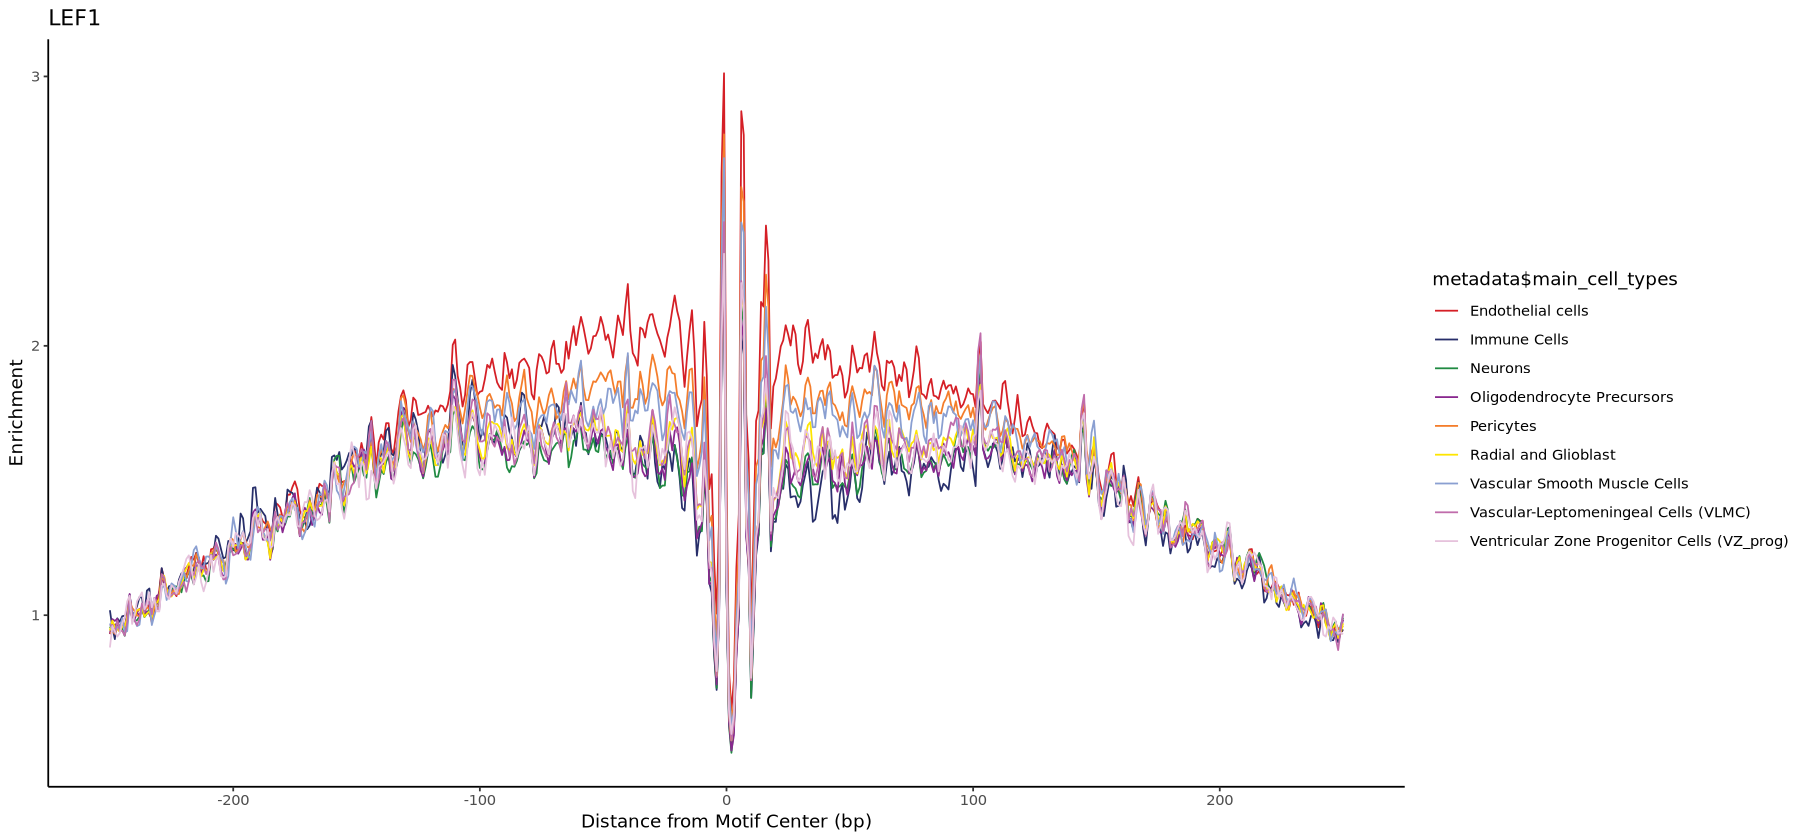

In [147]:
analyze_single_tf_footprint(tf_name = 'LEF1', peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata)

Motifs selected: MECOM



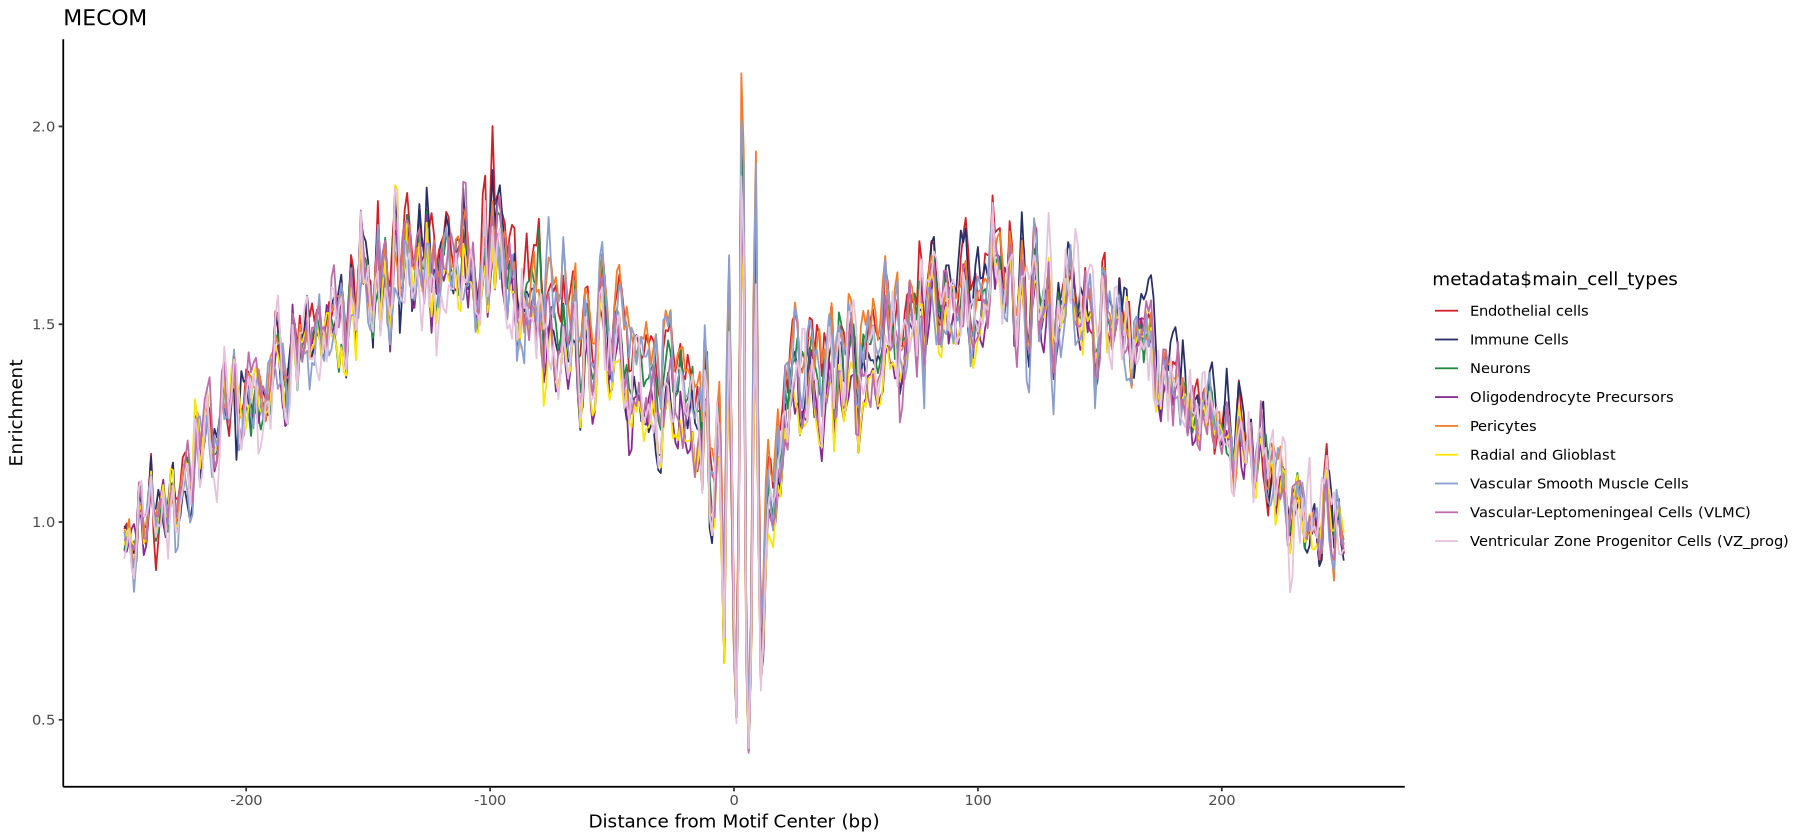

In [148]:
analyze_single_tf_footprint(tf_name = 'MECOM', peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata)

Motifs selected: KLF4



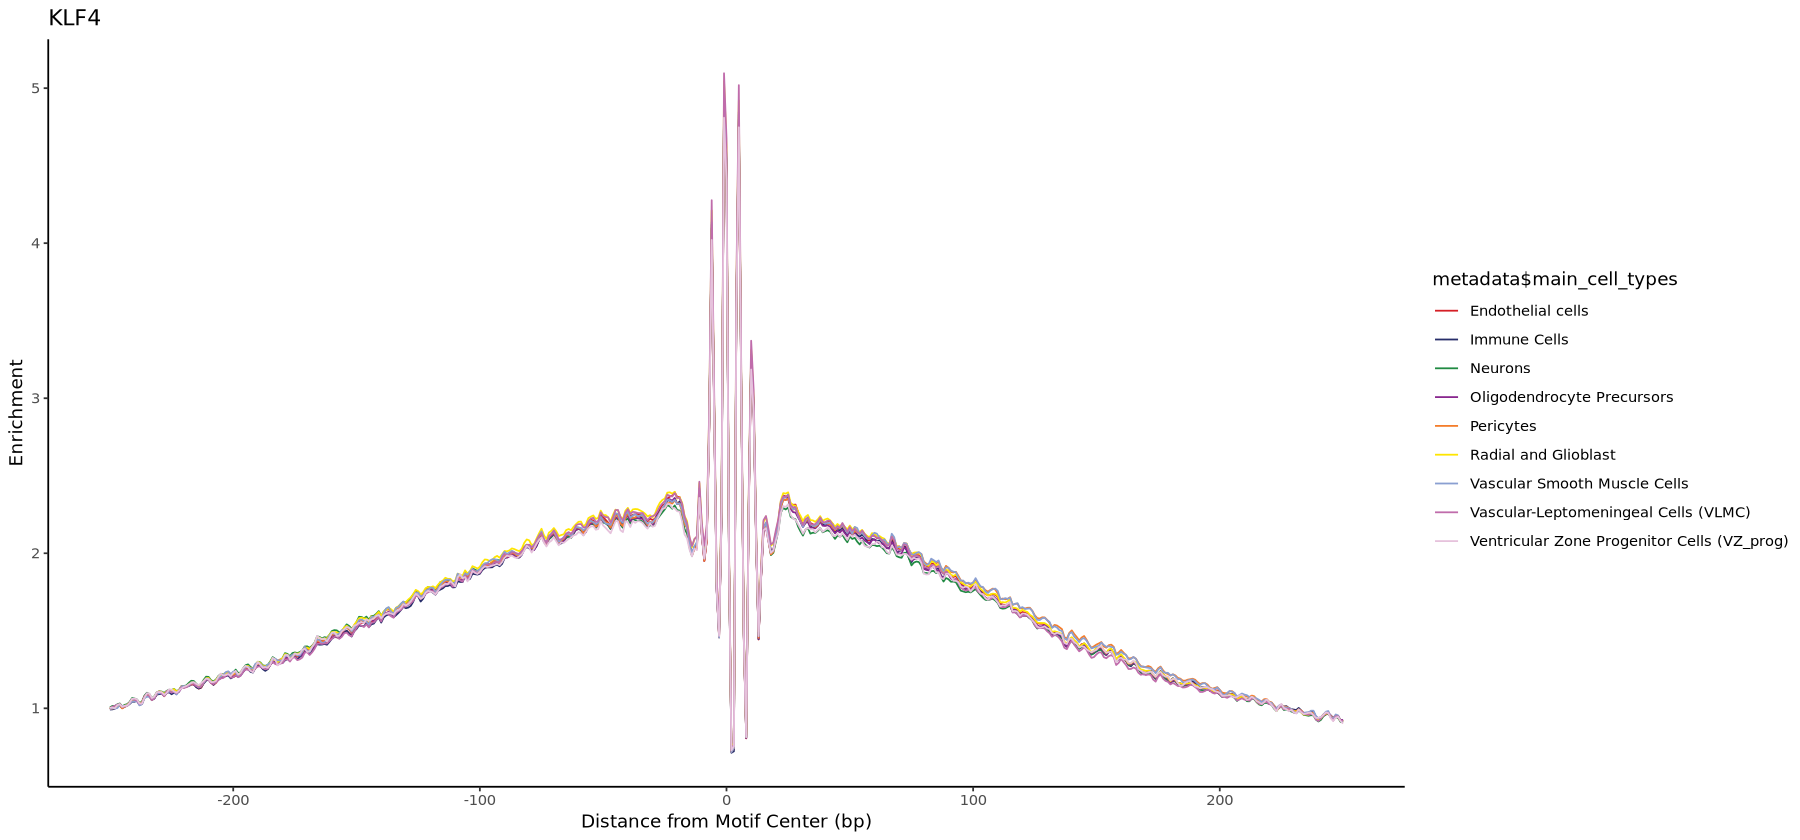

In [149]:
analyze_single_tf_footprint(tf_name = 'KLF4', peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata)

Motifs selected: FOXO1



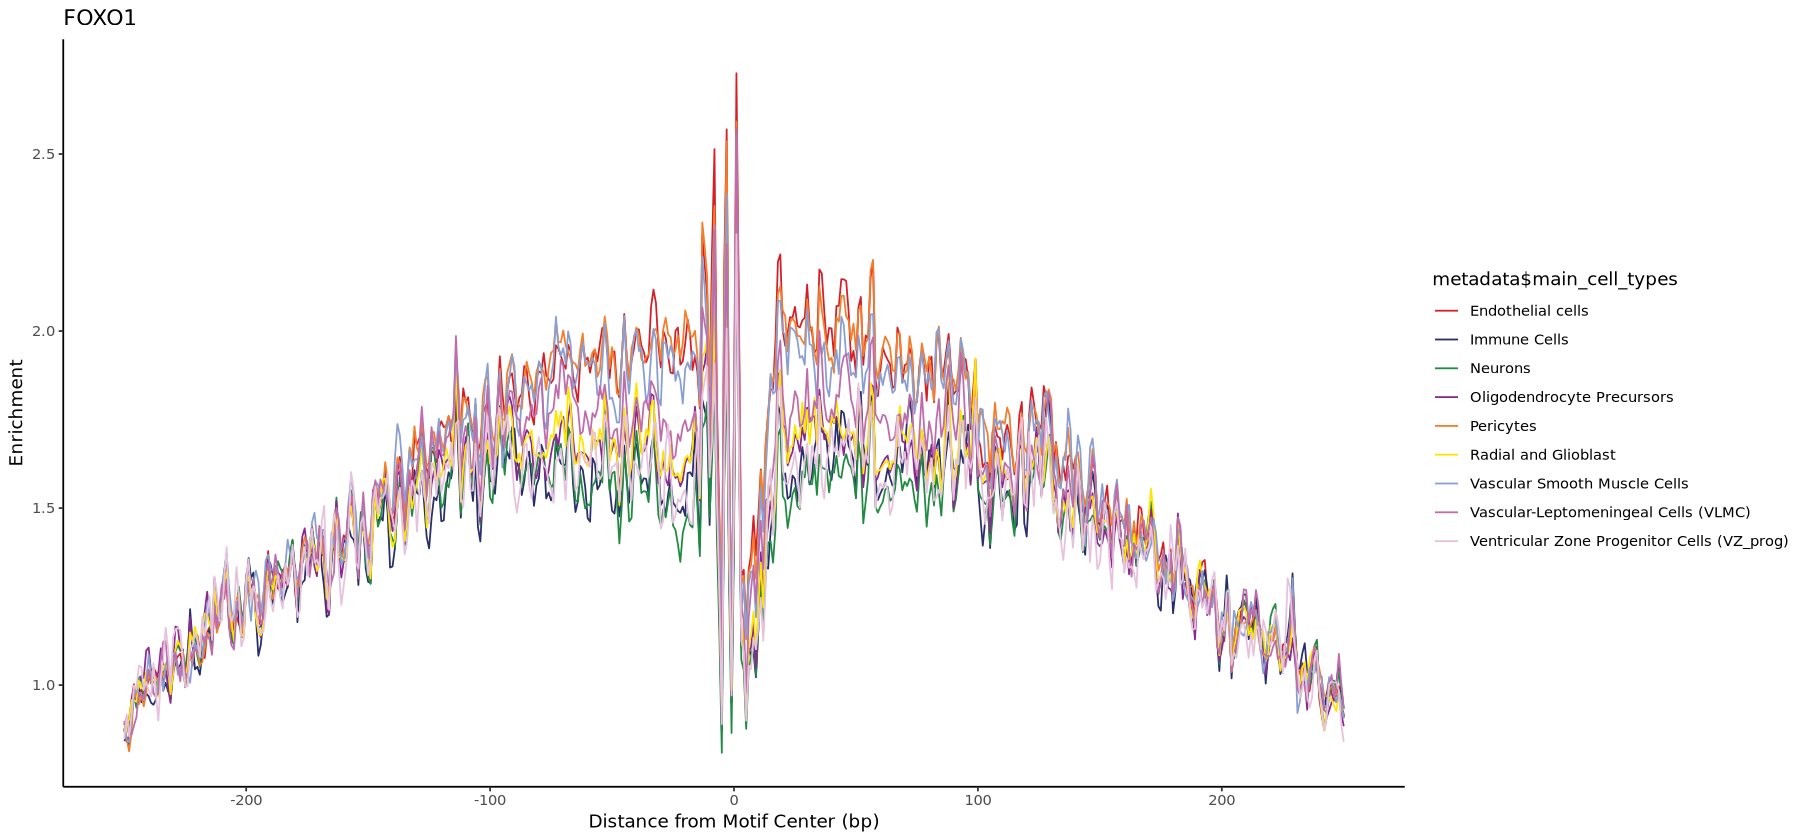

In [152]:
analyze_single_tf_footprint(tf_name = 'FOXO1', peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata)

In [155]:
analyze_multiple_tf_footprints <- function(tf_names, peaks_gr, subsetted_cells, metadata) {
  suppressPackageStartupMessages({
    library(stringr)
    library(motifmatchr)
    library(chromVARmotifs)
    library(ggplot2)
    library(patchwork)
  })
  
  # Ensure input is a character vector
  if (!is.character(tf_names)) {
    stop("tf_names must be a character vector of transcription factor names.")
  }
  
  # Find motif names for each TF
  motif_matches <- unlist(lapply(tf_names, function(tf) {
    names(my_human_pwms_v2) |> str_subset(pattern = tf)
  }))
  
  if (length(motif_matches) == 0) {
    stop("No motifs found for the given TF names. Check the input names.")
  }
  
  # Create a named vector (TF names as keys, matched motif IDs as values)
  selected_motifs <- setNames(motif_matches, tf_names)
  
  message("Motifs selected: ", paste(names(selected_motifs), collapse = ", "))
  
  # Run motif matching
  suppressWarnings({
    motif_positions <- motifmatchr::matchMotifs(
      chromVARmotifs::human_pwms_v2[selected_motifs], 
      peaks_gr, genome = "hg38", out = "positions"
    )
  })
  
  names(motif_positions) <- names(selected_motifs)
  
  # Generate footprinting plots
  footprinting_plots <- lapply(names(selected_motifs), function(motif) {
    plot_tf_footprint(
      subsetted_cells,
      motif_positions[[motif]],
      cell_groups = metadata$main_cell_types,
      flank = 250,
      smooth = 2
    ) +
      ggplot2::labs(title = motif)
  })
  
  # Combine plots if multiple motifs are found
  if (length(footprinting_plots) == 1) {
    return(footprinting_plots[[1]])  # Return a single plot
  } else {
    return(patchwork::wrap_plots(footprinting_plots, guides = "collect", ncol = 1))  # Return combined plots
  }
}


Motifs selected: FOXO1, SOX17



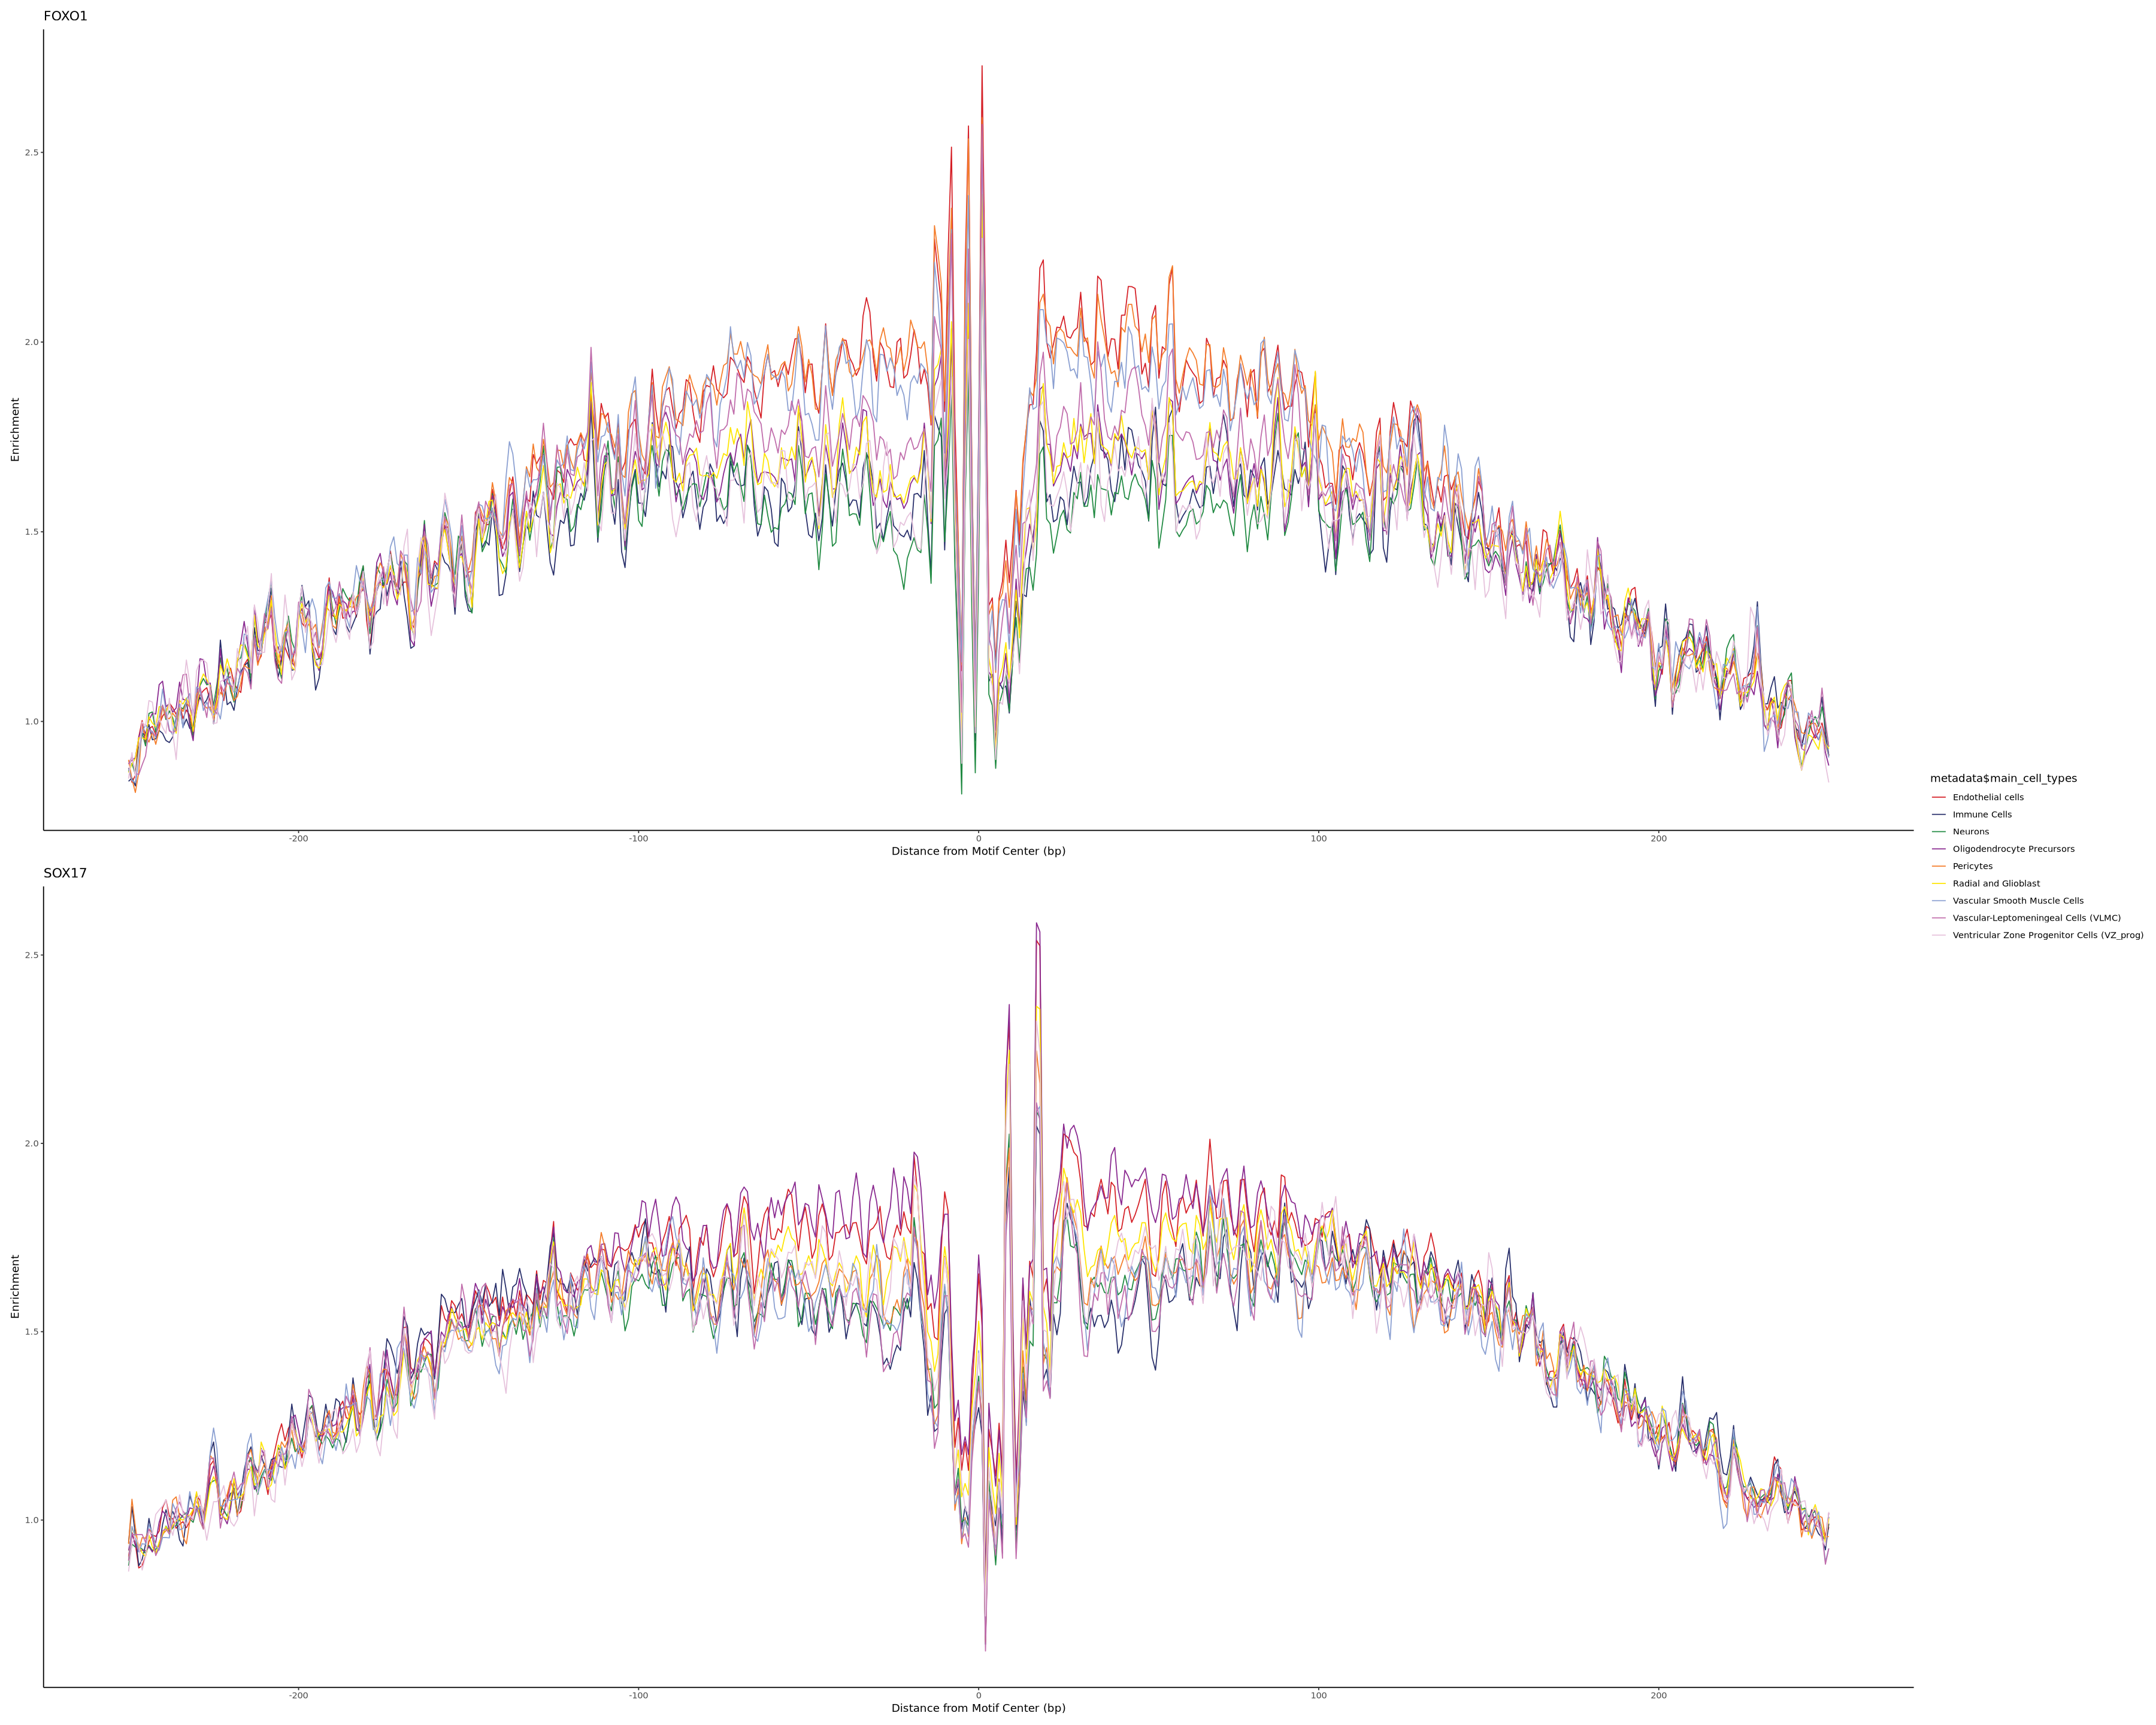

In [156]:
options(repr.plot.width = 30, repr.plot.height = 24)

analyze_multiple_tf_footprints(tf_name = c('FOXO1', 'SOX17'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata)

In [157]:
# with line thickness as option:

In [160]:
analyze_multiple_tf_footprints <- function(tf_names, peaks_gr, subsetted_cells, metadata, line_thickness = 1.5) {
  suppressPackageStartupMessages({
    library(stringr)
    library(motifmatchr)
    library(chromVARmotifs)
    library(ggplot2)
    library(patchwork)
  })
  
  if (!is.character(tf_names)) {
    stop("tf_names must be a character vector of transcription factor names.")
  }
  
  motif_matches <- unlist(lapply(tf_names, function(tf) {
    names(my_human_pwms_v2) |> str_subset(pattern = tf)
  }))
  
  if (length(motif_matches) == 0) {
    stop("No motifs found for the given TF names. Check the input names.")
  }
  
  selected_motifs <- setNames(motif_matches, tf_names)
  
  message("Motifs selected: ", paste(names(selected_motifs), collapse = ", "))
  
  suppressWarnings({
    motif_positions <- motifmatchr::matchMotifs(
      chromVARmotifs::human_pwms_v2[selected_motifs], 
      peaks_gr, genome = "hg38", out = "positions"
    )
  })
  
  names(motif_positions) <- names(selected_motifs)
  
  footprinting_plots <- lapply(names(selected_motifs), function(motif) {
    plot_tf_footprint(
      subsetted_cells,
      motif_positions[[motif]],
      cell_groups = metadata$main_cell_types,
      flank = 250,
      smooth = 2
    ) +
      ggplot2::labs(title = motif) +
      ggplot2::theme_minimal() +  # Clean theme
      ggplot2::theme(
        plot.title = ggplot2::element_text(size = 14, face = "bold")
      ) +
      ggplot2::guides(color = ggplot2::guide_legend(title = "Cell Type")) +
      ggplot2::geom_line(linewidth = line_thickness)  # Adjusts line thickness
  })
  
  if (length(footprinting_plots) == 1) {
    return(footprinting_plots[[1]])  
  } else {
    return(patchwork::wrap_plots(footprinting_plots, guides = "collect", ncol = 1))
  }
}


Motifs selected: FOXO1, SOX17



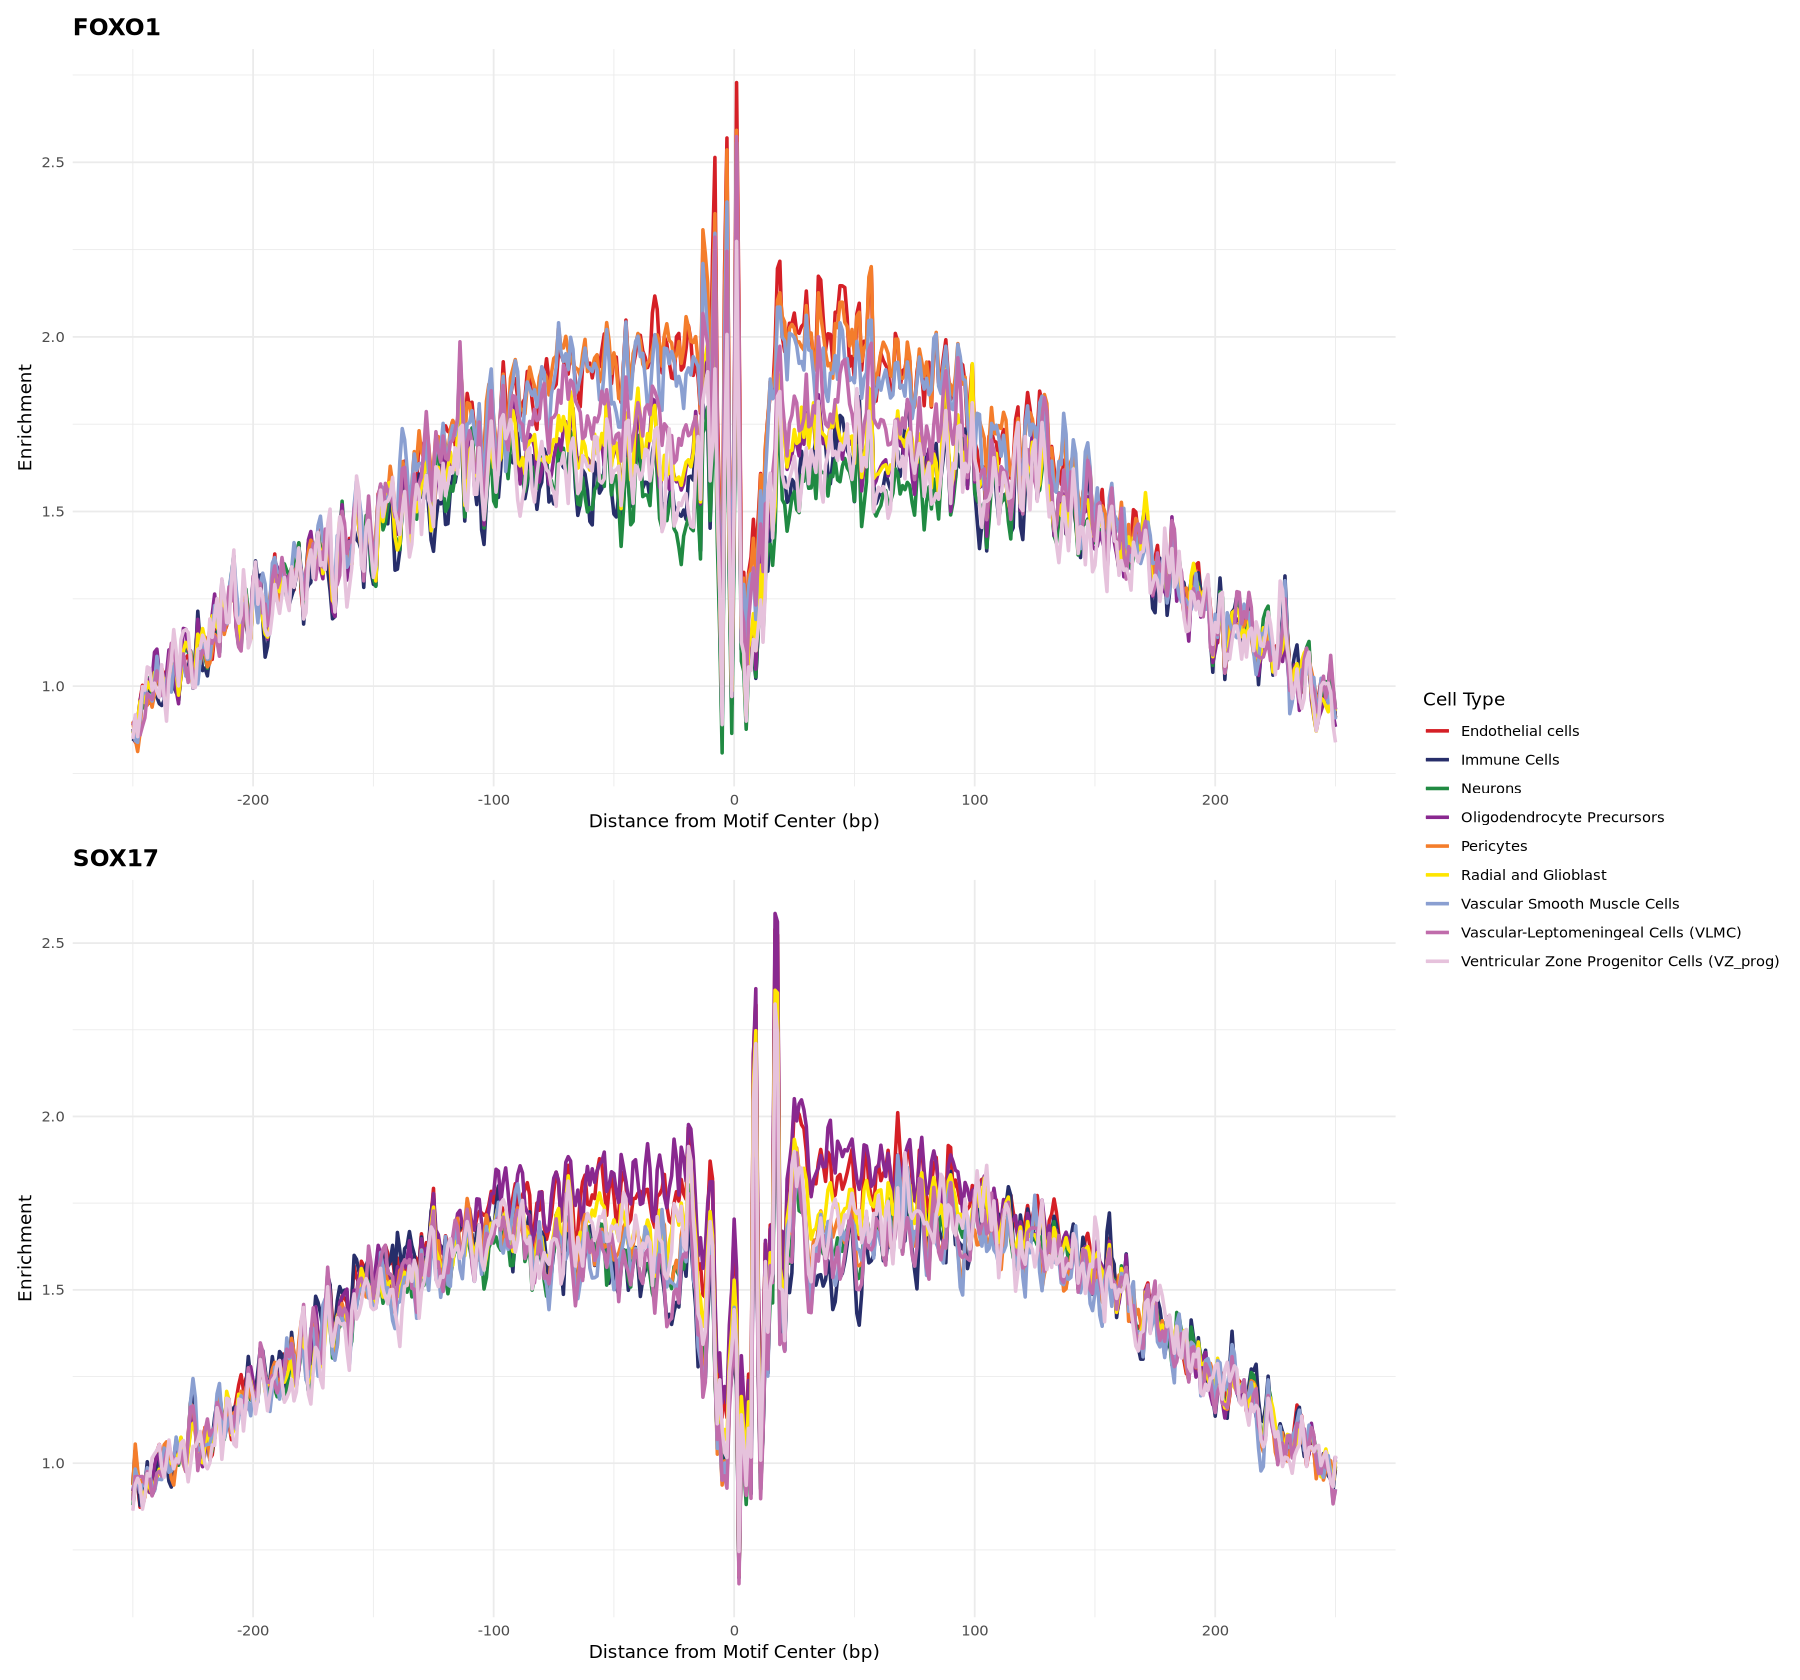

In [161]:
options(repr.plot.width = 15, repr.plot.height = 14)

analyze_multiple_tf_footprints(tf_name = c('FOXO1', 'SOX17'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

In [162]:
options(repr.plot.width = 15, repr.plot.height = 7)

In [165]:
ls()

[1] "add_prefix_to_cells"            "analyze_multiple_tf_footprints"
 [3] "analyze_single_tf_footprint"    "analyze_tf_footprint"          
 [5] "atac_qc"                        "atac_qc_test"                  
 [7] "blacklist"                      "bpcells_fragments"             
 [9] "bpcells_fragments_dir"          "bpcells_lib"                   
[11] "cell_ids"                       "cell_ids_correct"              
[13] "chrom_sizes"                    "footprinting_plots"            
[15] "frag_test"                      "fragment_objects"              
[17] "fragment_paths"                 "frags"                         
[19] "genes"                          "genome_annotation_dir"         
[21] "mat_lsi"                        "merged_fragments"              
[23] "metadata"                       "motif"                         
[25] "motif_positions"                "motif_selected"                
[27] "my_human_pwms_v2"               "peaks_gr"                      
[29] "peaks_sorted"                   "prefixed_fragments"            
[31] "prefixes"                       "selected_motifs"               
[33] "subsetted_cells"                "temp_DF"

Motifs selected: ETS1



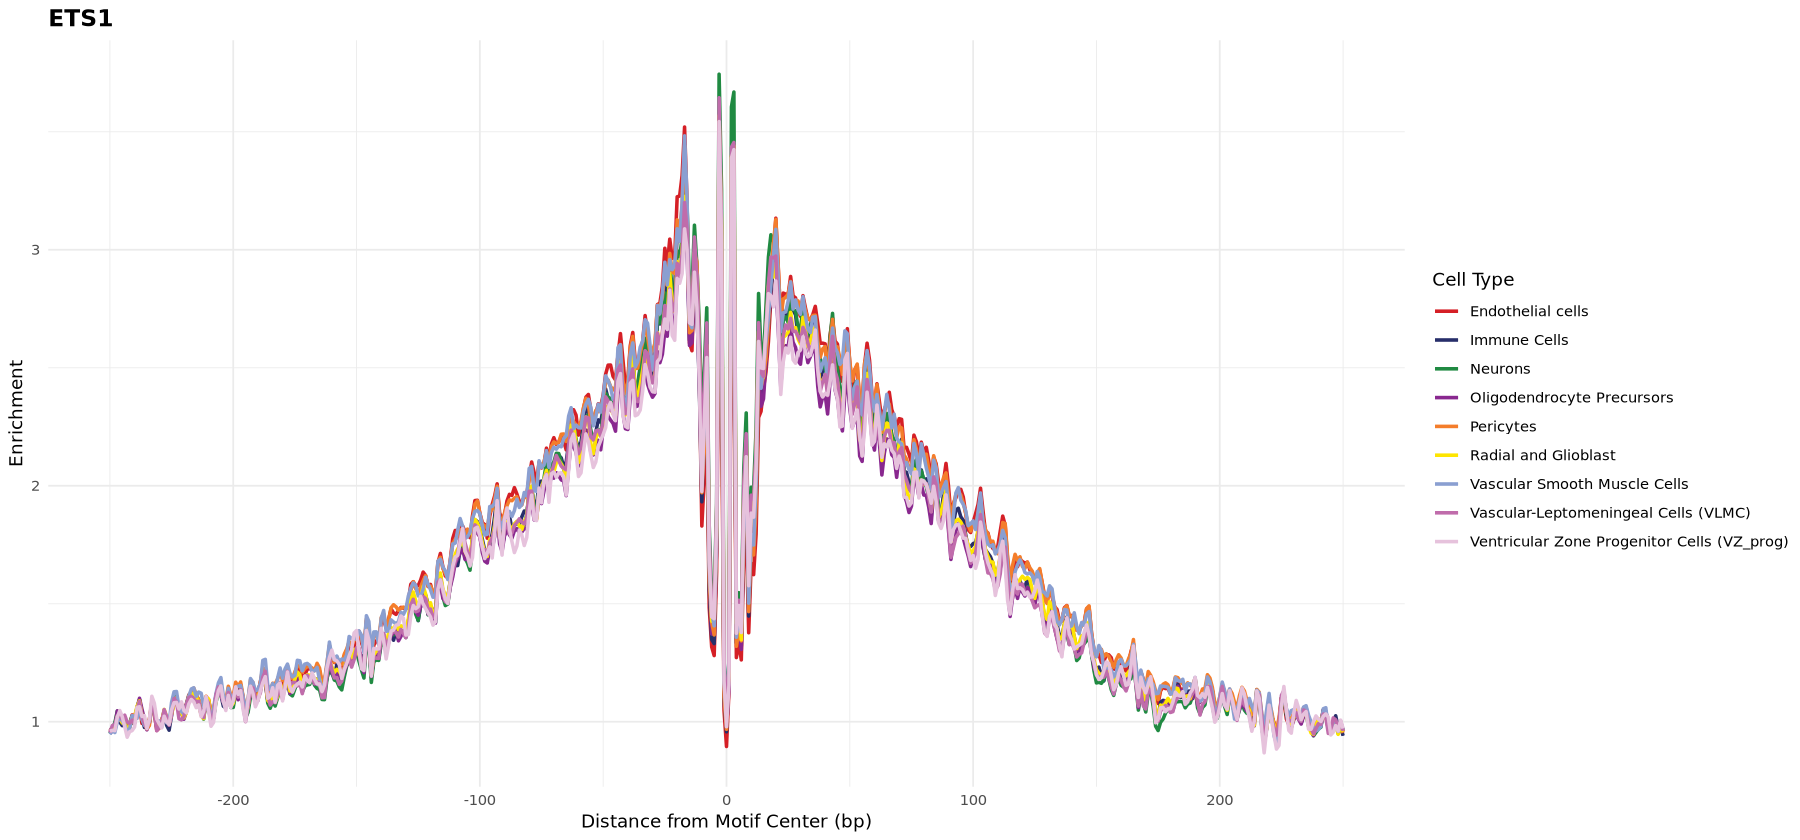

In [166]:
analyze_multiple_tf_footprints(tf_name = c('ETS1'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

Motifs selected: HAND2



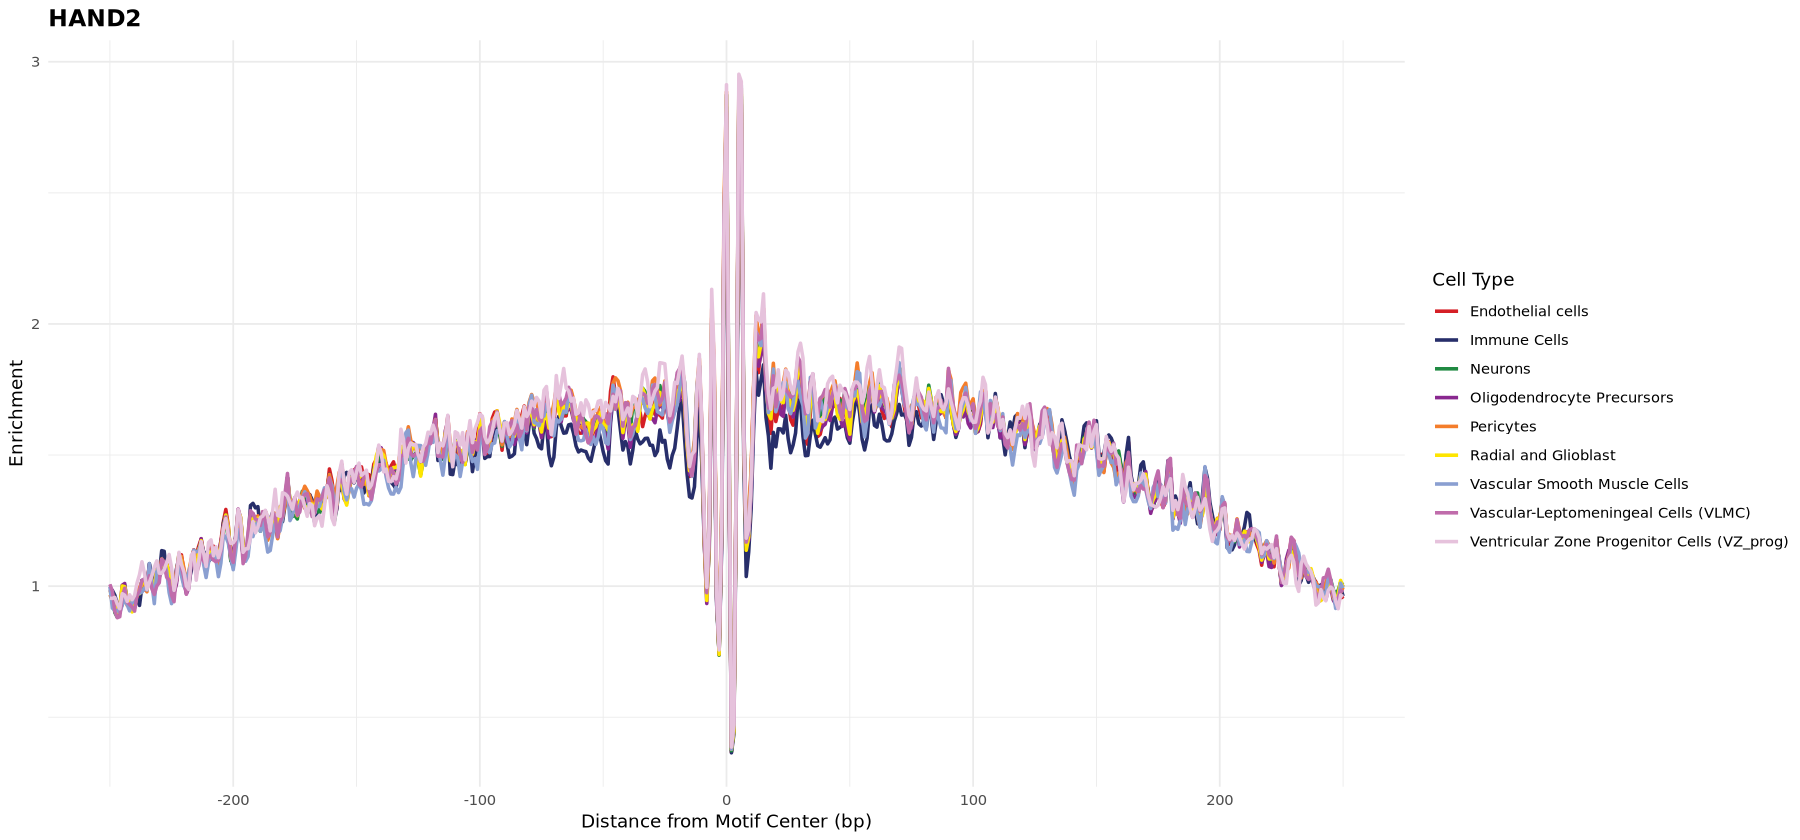

In [167]:
analyze_multiple_tf_footprints(tf_name = c('HAND2'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

Motifs selected: SOX18



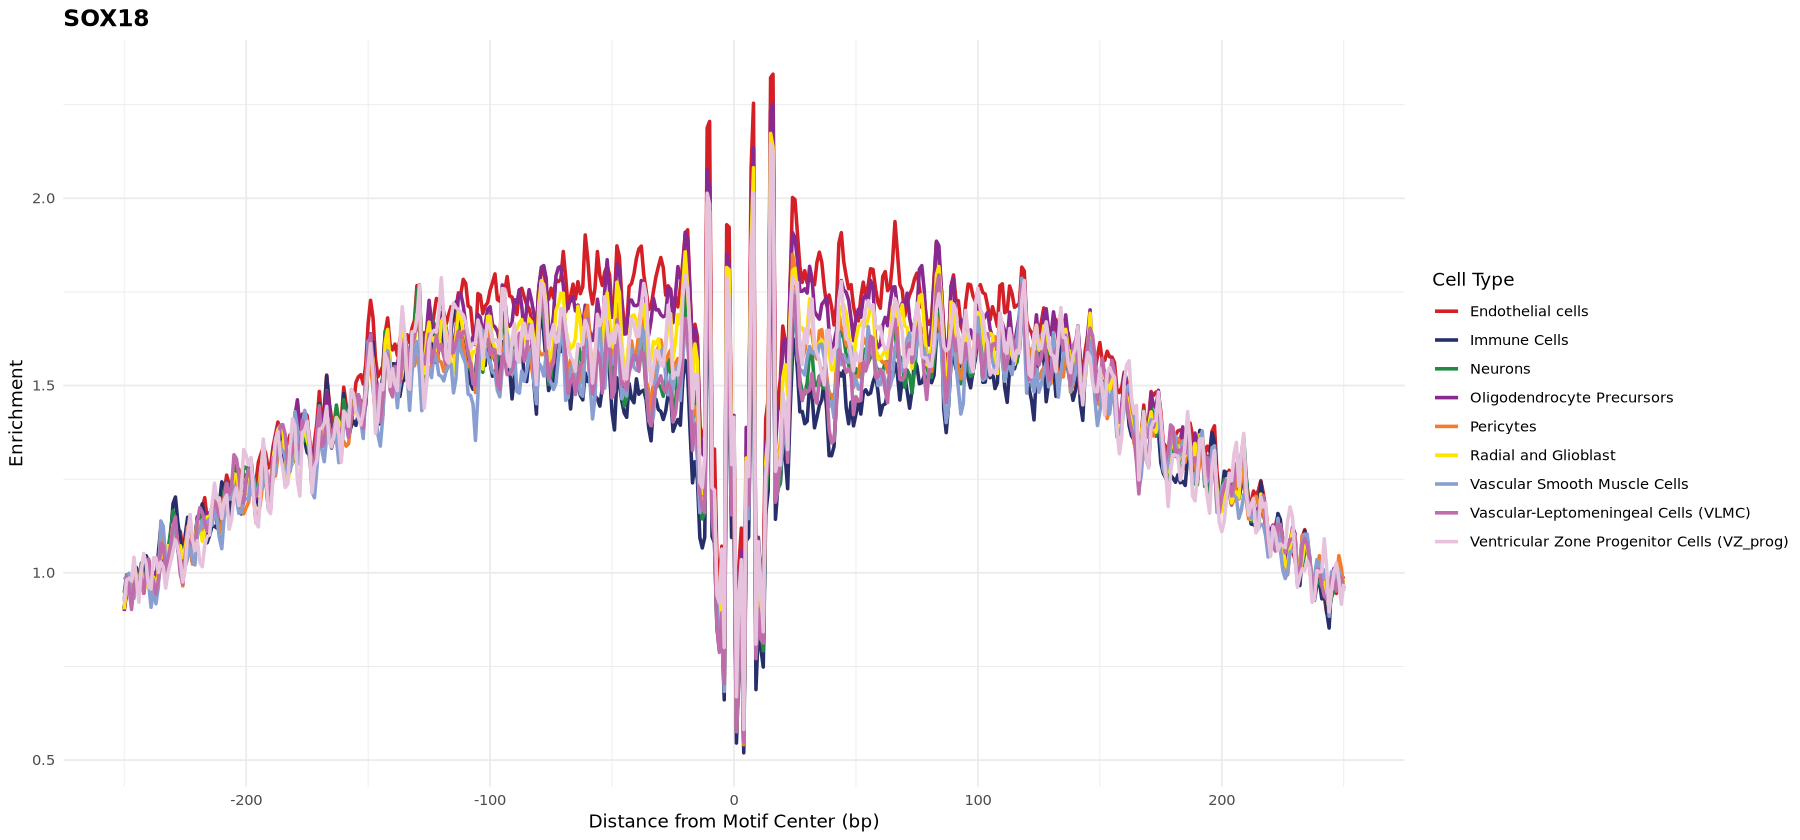

In [168]:
analyze_multiple_tf_footprints(tf_name = c('SOX18'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

Motifs selected: BHLHE40



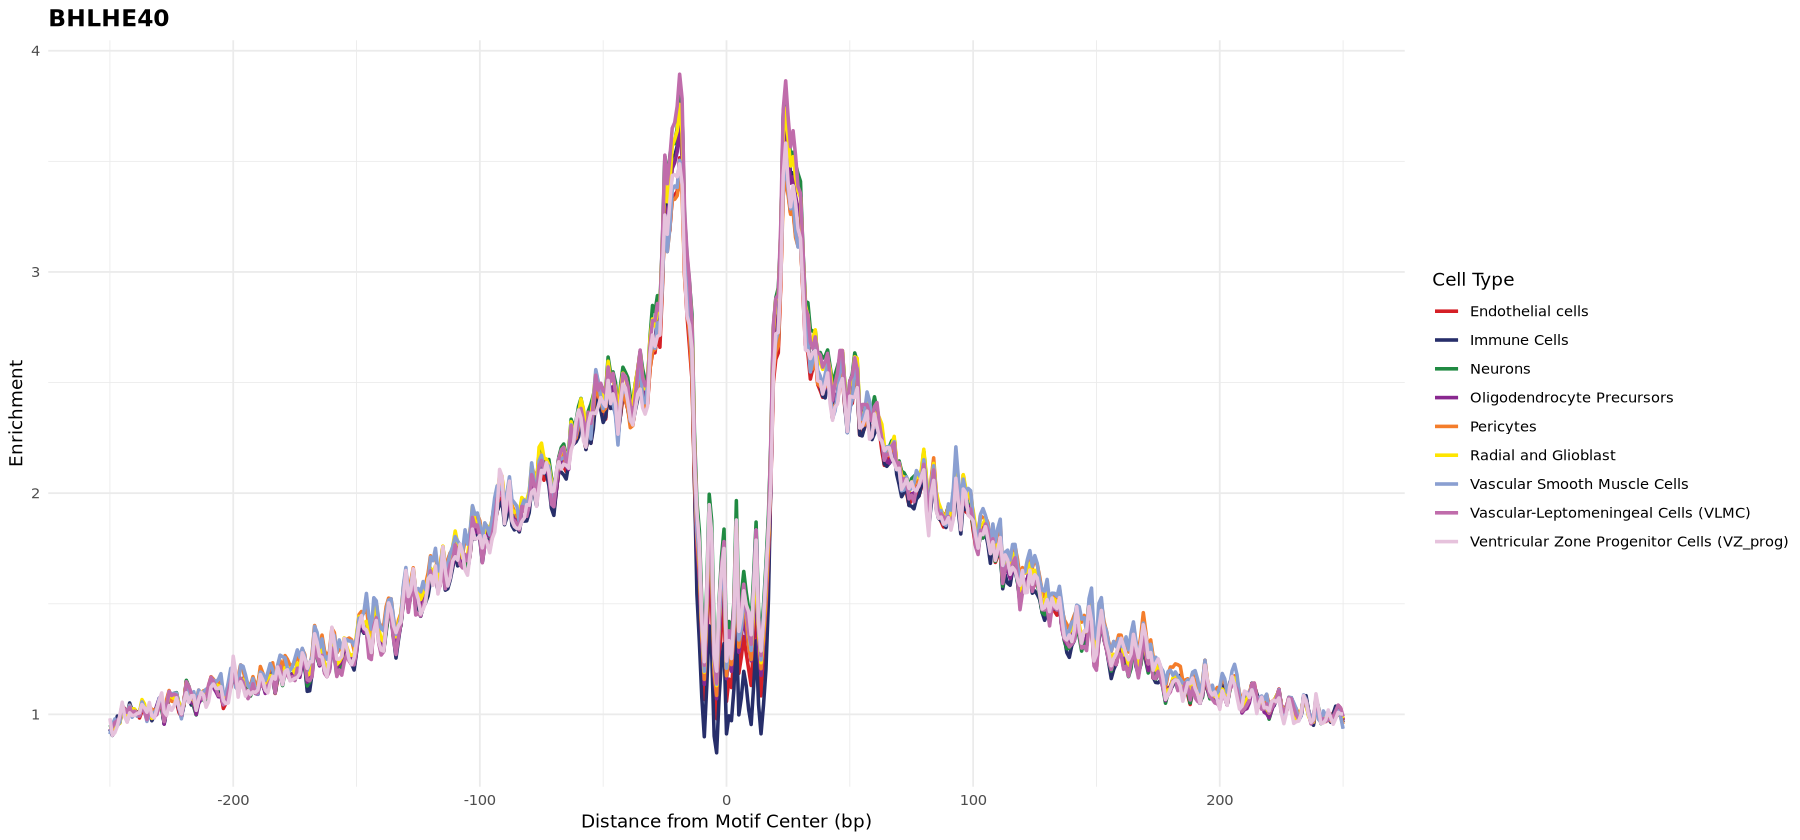

In [169]:
analyze_multiple_tf_footprints(tf_name = c('BHLHE40'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

Motifs selected: PAX7



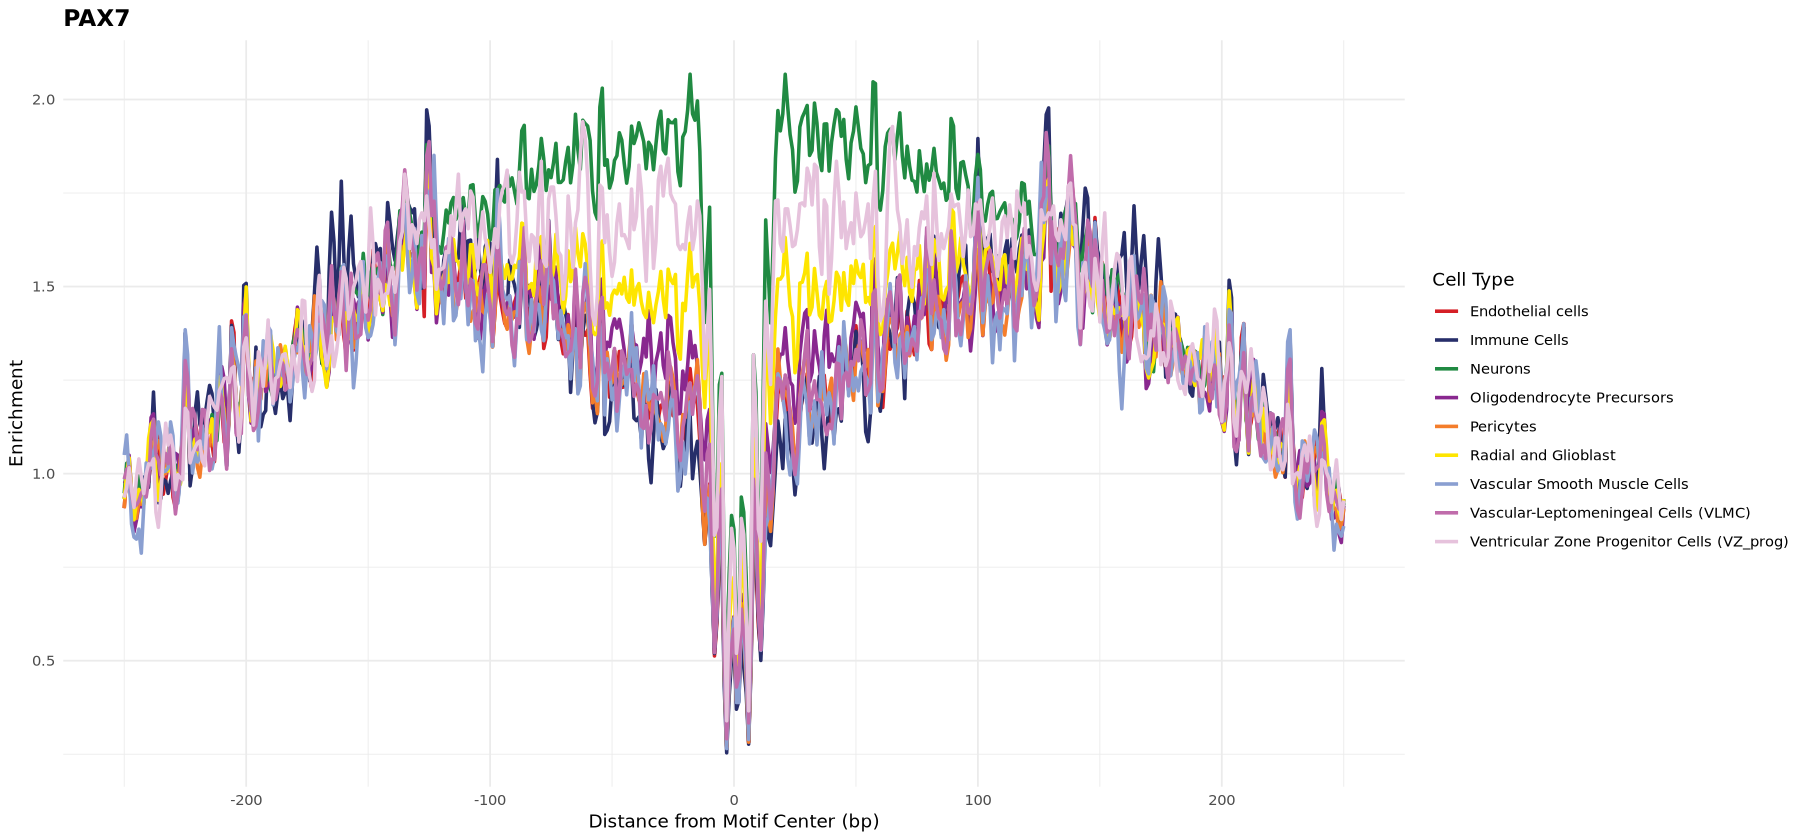

In [172]:
analyze_multiple_tf_footprints(tf_name = c('PAX7'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

Motifs selected: HOXC10



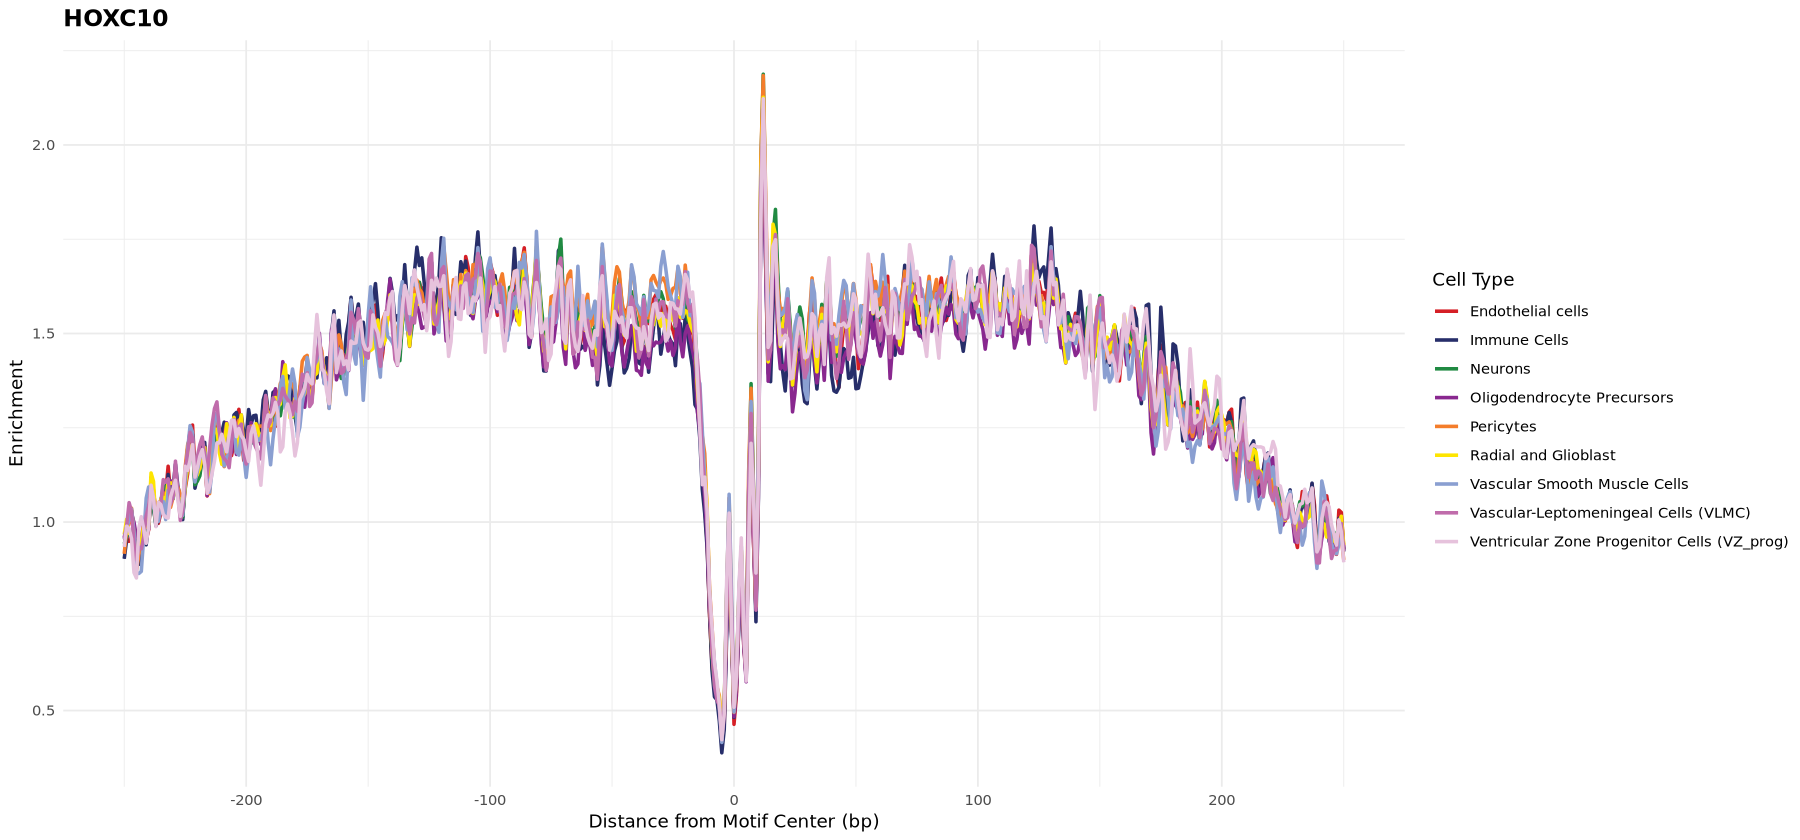

In [173]:
analyze_multiple_tf_footprints(tf_name = c('HOXC10'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

Motifs selected: MECOM



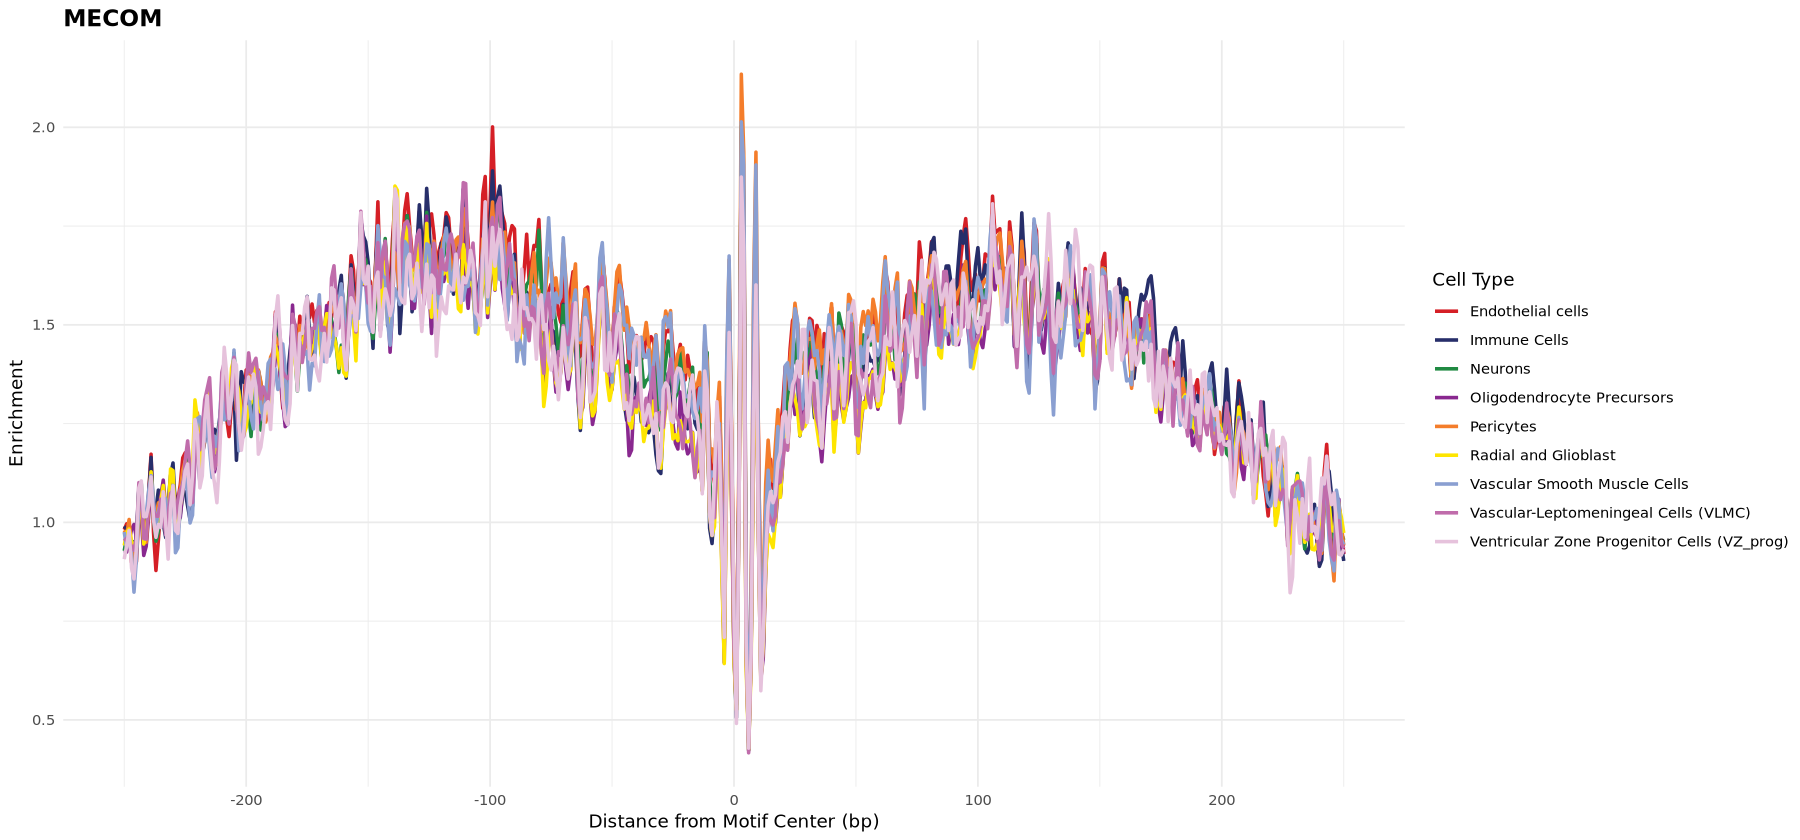

In [182]:
analyze_multiple_tf_footprints(tf_name = c('MECOM'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

Motifs selected: HIF1



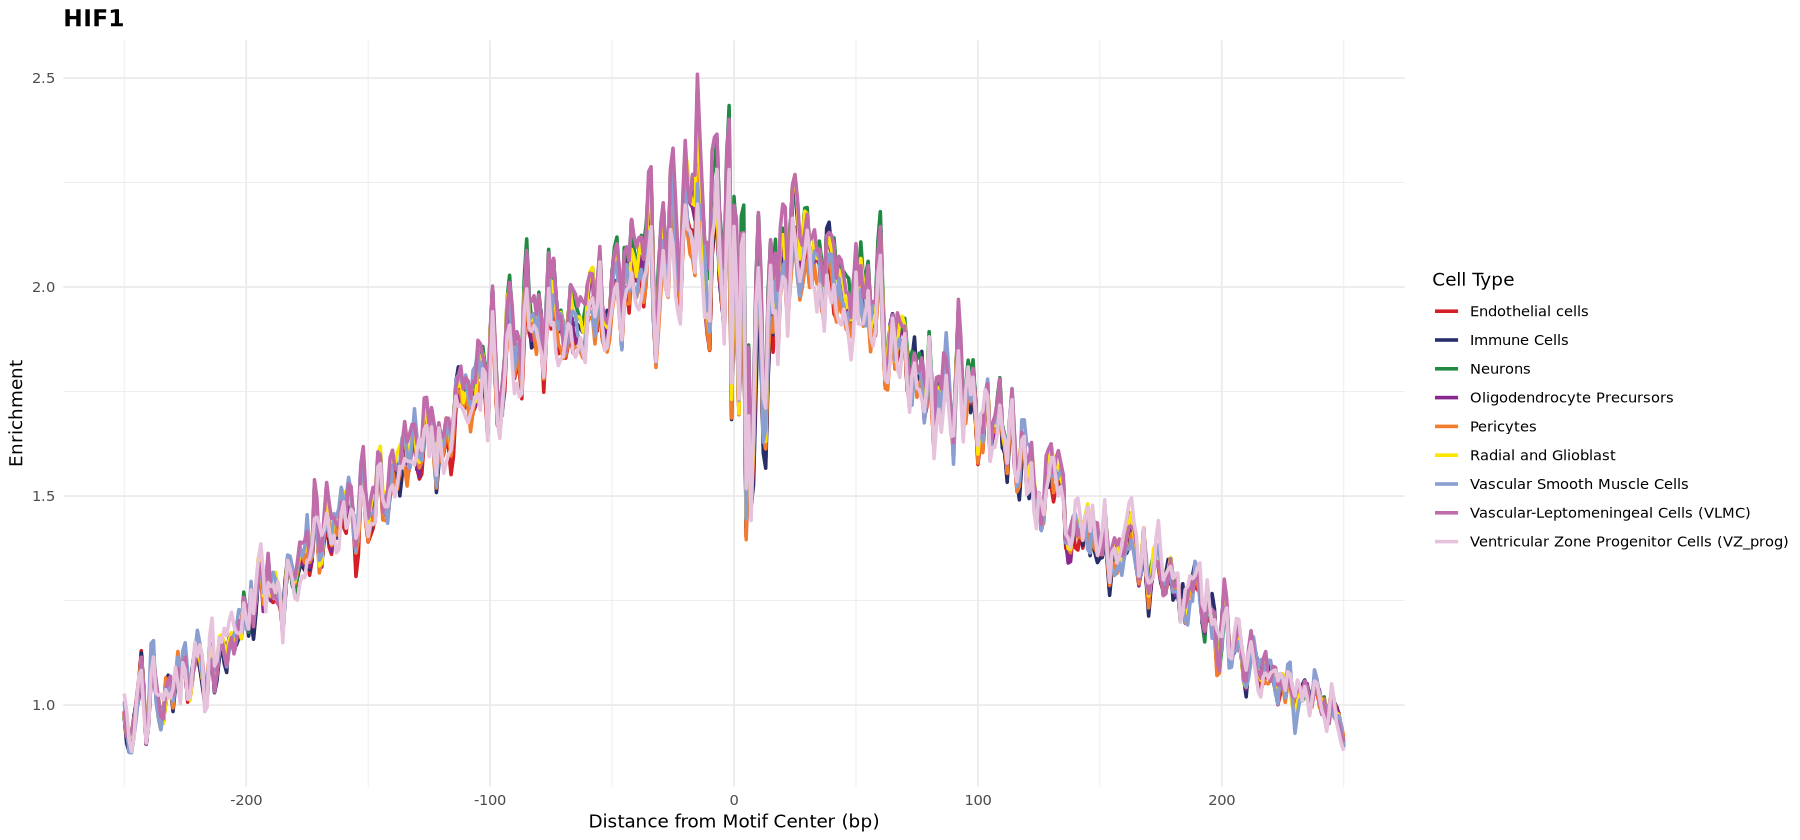

In [183]:
analyze_multiple_tf_footprints(tf_name = c('HIF1'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

Motifs selected: PHOX2B



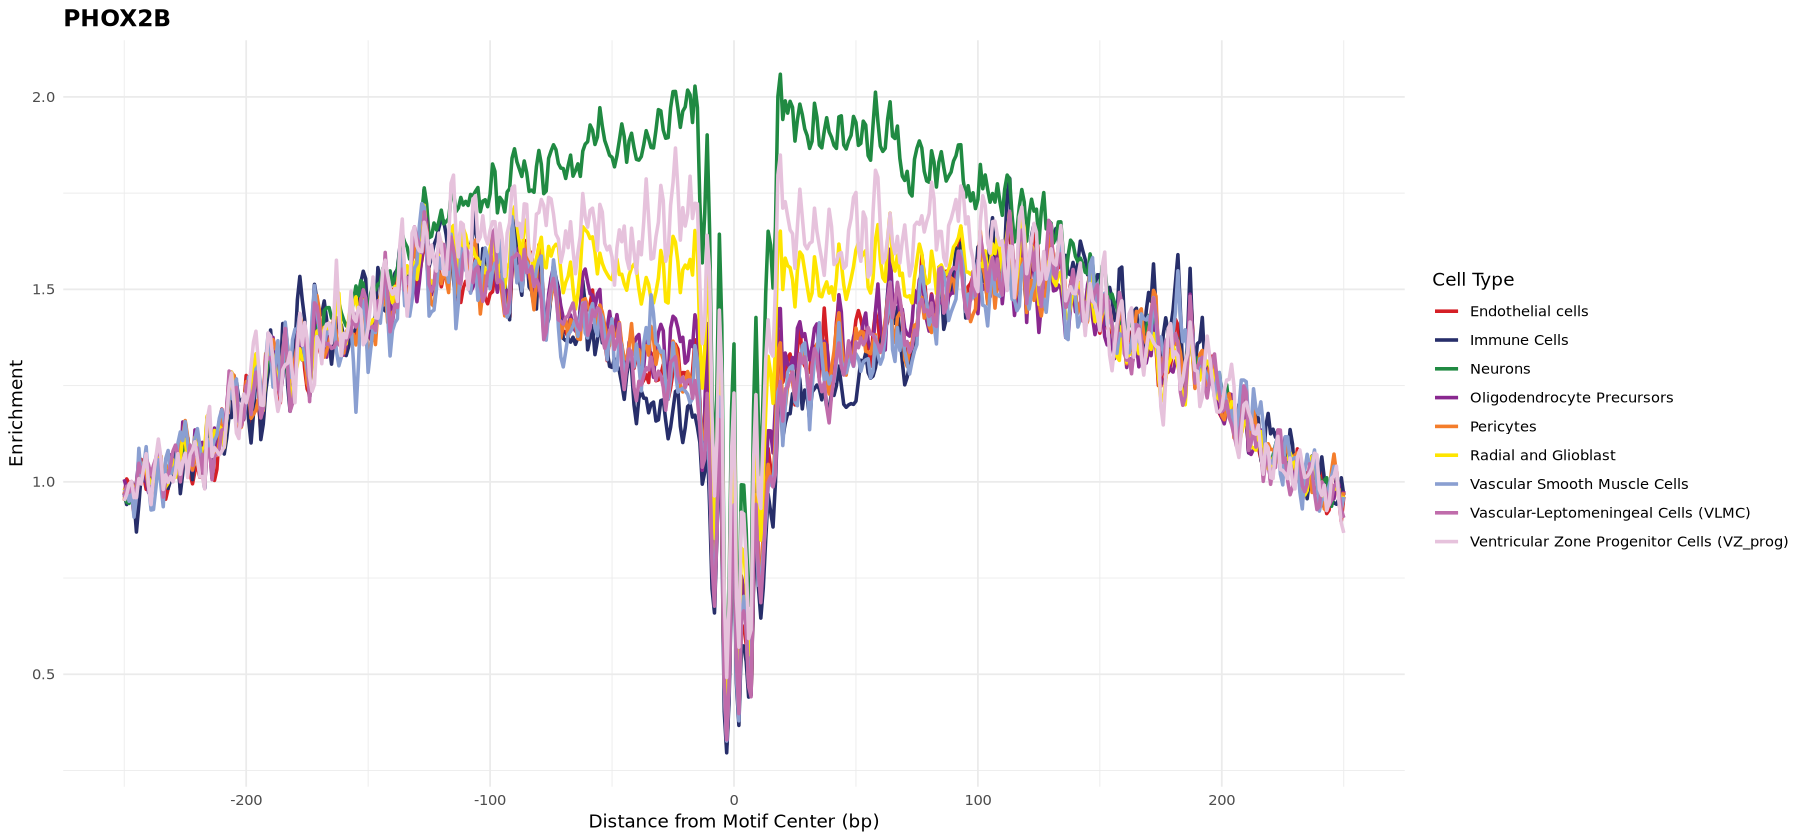

In [184]:
analyze_multiple_tf_footprints(tf_name = c('PHOX2B'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

Motifs selected: TBX18



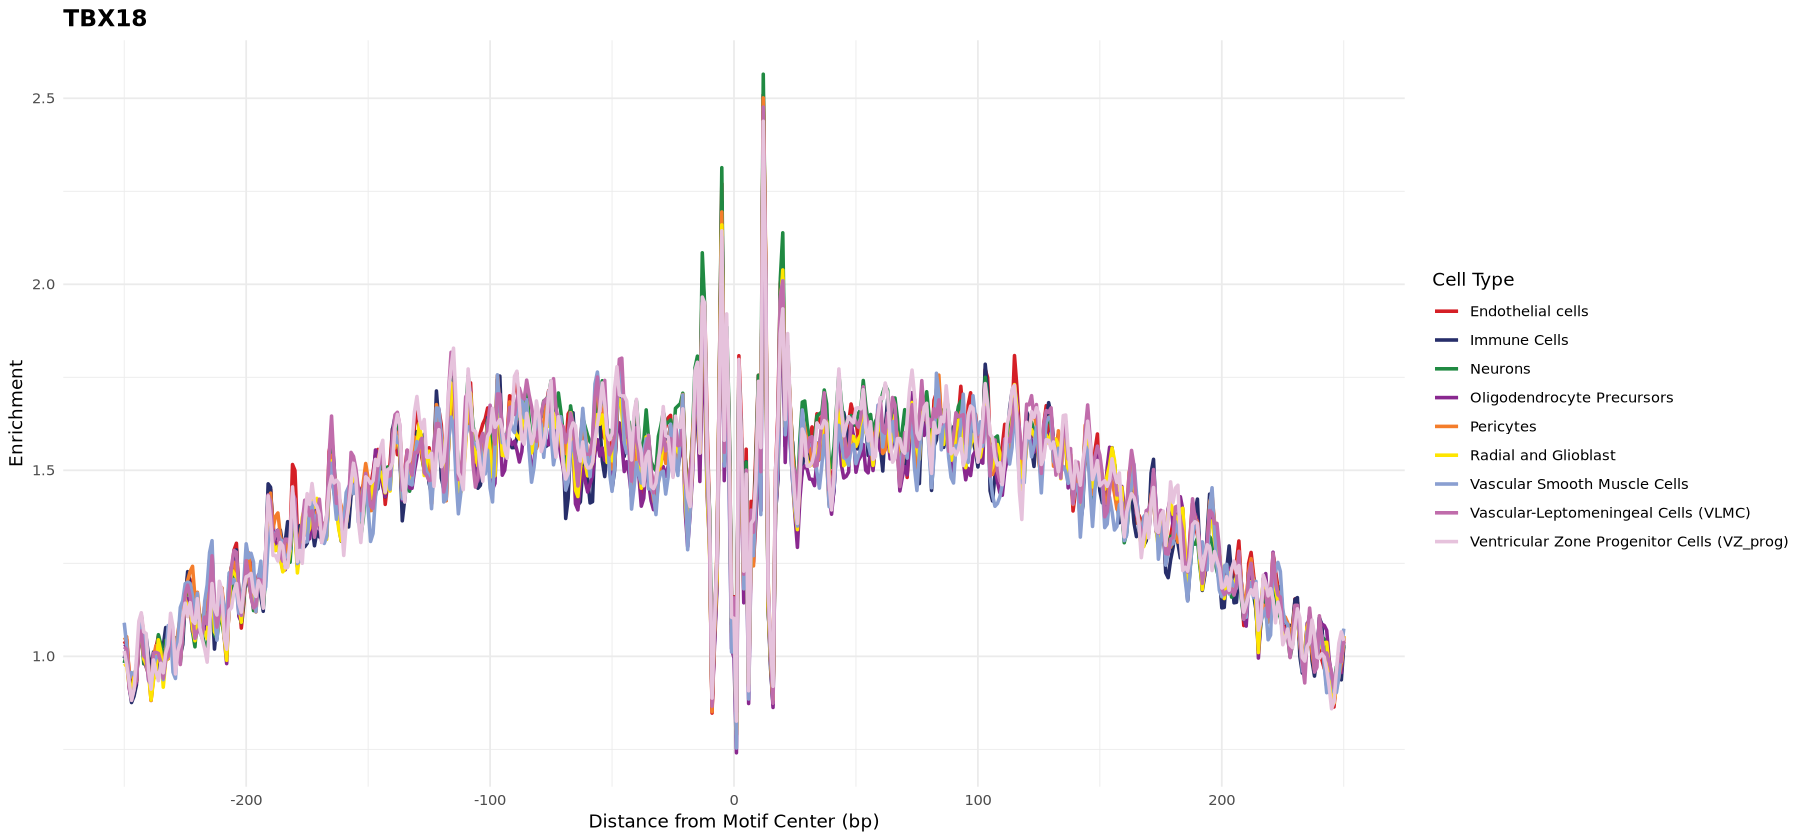

In [186]:
analyze_multiple_tf_footprints(tf_name = c('TBX18'), peaks_gr = peaks_gr, subsetted_cells = subsetted_cells, metadata = metadata, line_thickness = 1)

In [188]:
sessionInfo

function (package = NULL) 
{
    z <- list()
    z$R.version <- R.Version()
    z$platform <- z$R.version$platform
    if (nzchar(.Platform$r_arch)) 
        z$platform <- paste(z$platform, .Platform$r_arch, sep = "/")
    sp <- 8 * .Machine$sizeof.pointer
    if (sp != 64) 
        z$platform <- paste0(z$platform, " (", sp, "-bit)")
    z$locale <- Sys.getlocale()
    z$tzone <- Sys.timezone()
    z$tzcode_type <- .Call(C_tzcode_type)
    z$running <- osVersion
    z$RNGkind <- RNGkind()
    if (is.null(package)) {
        package <- grep("^package:", search(), value = TRUE)
        keep <- vapply(package, function(x) x == "package:base" || 
            !is.null(attr(as.environment(x), "path")), NA)
        package <- .rmpkg(package[keep])
    }
    pkgDesc <- lapply(package, packageDescription, encoding = NA)
    if (length(package) == 0) 
        stop("no valid packages were specified")
    basePkgs <- sapply(pkgDesc, function(x) !is.null(x$Priority) && 
        x$Priority == "base")
    z$basePkgs <- package[basePkgs]
    if (any(!basePkgs)) {
        z$otherPkgs <- pkgDesc[!basePkgs]
        names(z$otherPkgs) <- package[!basePkgs]
    }
    loadedOnly <- loadedNamespaces()
    loadedOnly <- loadedOnly[!(loadedOnly %in% package)]
    if (length(loadedOnly)) {
        names(loadedOnly) <- loadedOnly
        pkgDesc <- c(pkgDesc, lapply(loadedOnly, packageDescription, 
            encoding = NA))
        z$loadedOnly <- pkgDesc[loadedOnly]
    }
    z$matprod <- as.character(options("matprod"))
    es <- extSoftVersion()
    z$BLAS <- es[["BLAS"]]
    z$LAPACK <- La_library()
    z$LA_version <- La_version()
    l10n <- l10n_info()
    if (!is.null(l10n[["system.codepage"]])) 
        z$system.codepage <- l10n[["system.codepage"]]
    if (!is.null(l10n[["codepage"]])) 
        z$codepage <- l10n[["codepage"]]
    class(z) <- "sessionInfo"
    z
}
<bytecode: 0xdfdb5ce0>
<environment: namespace:utils>